# Set-up colab


In [1]:
#online for colab environment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/USA
from fairness_metric_utils import *
from penalty_utils import *

/content/drive/MyDrive/USA


In [3]:
%cd /content/drive/MyDrive/USA/AdultCensus

/content/drive/MyDrive/USA/AdultCensus


# Load Data

In [4]:
dataset_path = 'adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=[ 'PPE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP'] #'GFA', 'PPA', 'FPR', 'PPE', 'FPA', 'OAE', 'EOP', 'FNP', 'FPP'
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


#Compute Fairness

In [9]:
pairs_dict= {}
fairness_metrics_dict= {}
differences = {}
s= []
for i in range(1,len(protected_attributes)+1):
  pairs_dict[i] = ['-'.join(pair) for pair in combinations(protected_attributes, i)]
#print(pairs_dict)

for i in range(1, len(protected_attributes)+1):
  df=pd.read_csv(dataset_path)
  for sensible_attribute in pairs_dict[i]:
    s = sensible_attribute.split('-')
    print(s)
    if len(s)>1:
      df=pd.read_csv(dataset_path)
      df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
      df = df.drop(columns=s)
    fairness_metrics_dict[sensible_attribute], differences[sensible_attribute] = get_attribute_analysis(df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping,target_variable_labels)

['age']
PPE {1: 0.14198071866783524, 0: 0.014448669201520912}
Max value: 0.142 (Key: 1)
Min value: 0.014 (Key: 0)
Max-min: 0.128
FPR {1: 0.27030033370411566, 0: 0.22440944881889763}
Max value: 0.27 (Key: 1)
Min value: 0.224 (Key: 0)
Max-min: 0.046
FPA {1: 0.15554916618746406, 0: 0.08280254777070063}
Max value: 0.156 (Key: 1)
Min value: 0.083 (Key: 0)
Max-min: 0.073
EOP {1: 0.291958985429034, 0: 0.6405109489051095}
Max value: 0.641 (Key: 0)
Min value: 0.292 (Key: 1)
Max-min: 0.349
FNP {1: 0.10253980288097043, 0: 0.0781215223681282}
Max value: 0.103 (Key: 1)
Min value: 0.078 (Key: 0)
Max-min: 0.025
FPP {1: 0.09211523881728582, 0: 0.012686401068328511}
Max value: 0.092 (Key: 1)
Min value: 0.013 (Key: 0)
Max-min: 0.079
['sex']
PPE {0: 0.020703933747412008, 1: 0.11409395973154363}
Max value: 0.114 (Key: 1)
Min value: 0.021 (Key: 0)
Max-min: 0.093
FPR {0: 0.2564102564102564, 1: 0.275377969762419}
Max value: 0.275 (Key: 1)
Min value: 0.256 (Key: 0)
Max-min: 0.019
FPA {0: 0.06181818181818182, 

# Print plots

In [10]:
df=pd.read_csv(dataset_path)

In [11]:
print(fairness_metrics_dict)

{'age': {'PPE': {1: 0.14198071866783524, 0: 0.014448669201520912}, 'FPR': {1: 0.27030033370411566, 0: 0.22440944881889763}, 'FPA': {1: 0.15554916618746406, 0: 0.08280254777070063}, 'EOP': {1: 0.291958985429034, 0: 0.6405109489051095}, 'FNP': {1: 0.10253980288097043, 0: 0.0781215223681282}, 'FPP': {1: 0.09211523881728582, 0: 0.012686401068328511}}, 'sex': {'PPE': {0: 0.020703933747412008, 1: 0.11409395973154363}, 'FPR': {0: 0.2564102564102564, 1: 0.275377969762419}, 'FPA': {0: 0.06181818181818182, 1: 0.1498497209102619}, 'EOP': {0: 0.518005540166205, 1: 0.34215686274509804}, 'FNP': {0: 0.057379564283522554, 1: 0.10721966205837173}, 'FPP': {0: 0.01841055538508745, 1: 0.07834101382488479}}, 'race': {'PPE': {1: 0.08395872420262664, 0: 0.02263374485596708}, 'FPR': {1: 0.2685, 0: 0.27848101265822783}, 'FPA': {1: 0.11960931630353118, 0: 0.0821256038647343}, 'EOP': {1: 0.3523683045595396, 0: 0.5985915492957746}, 'FNP': {1: 0.09196995956094743, 0: 0.0763016157989228}, 'FPP': {1: 0.0620450606585

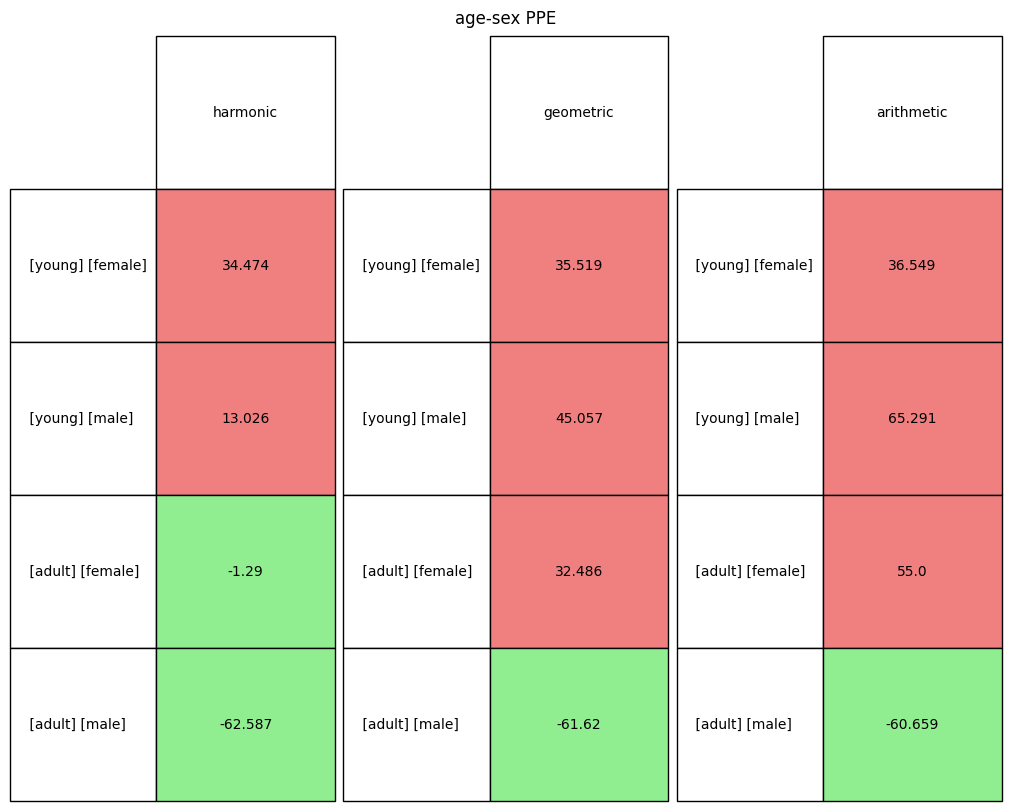

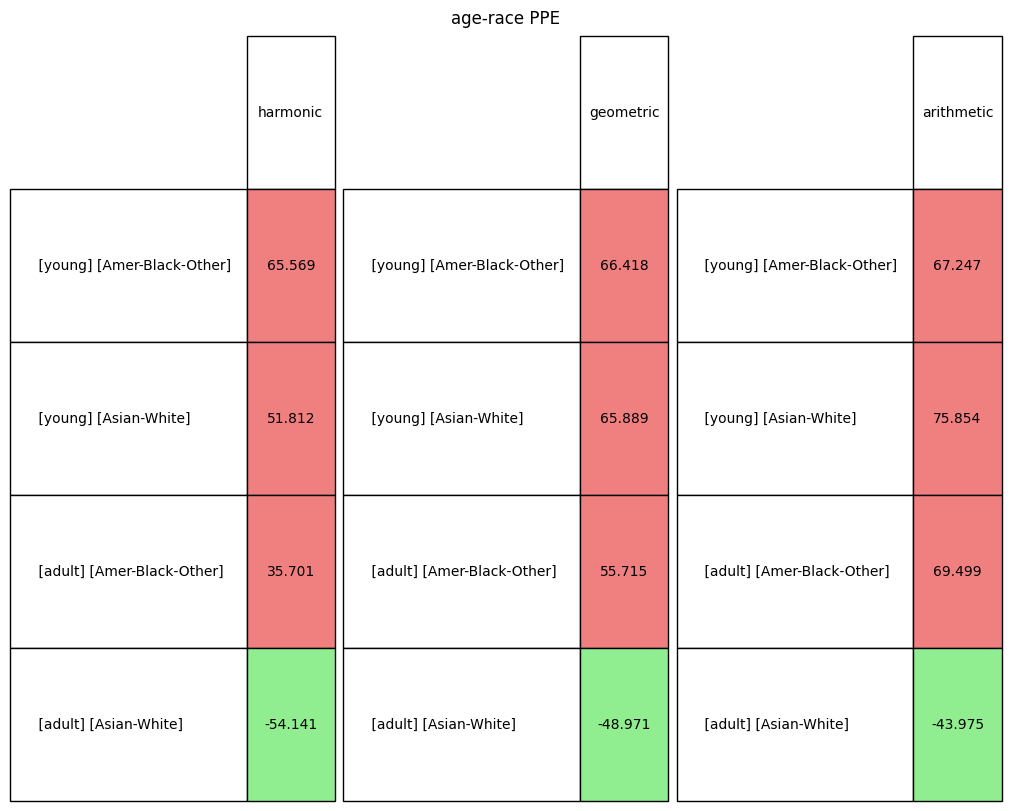

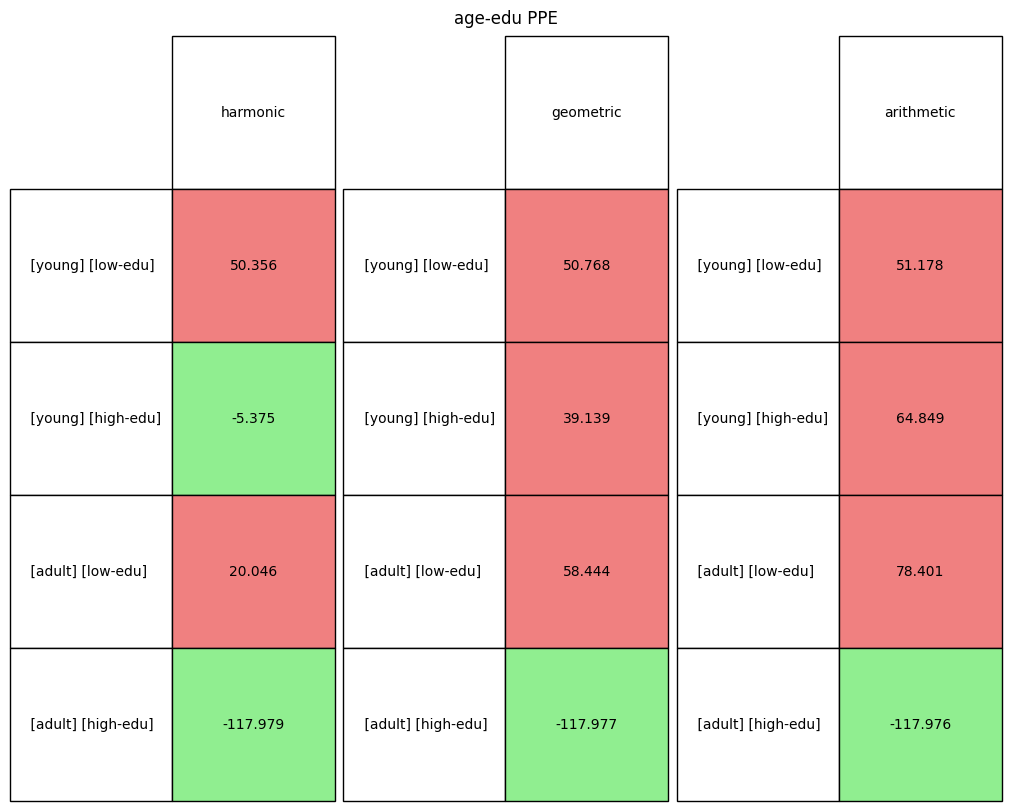

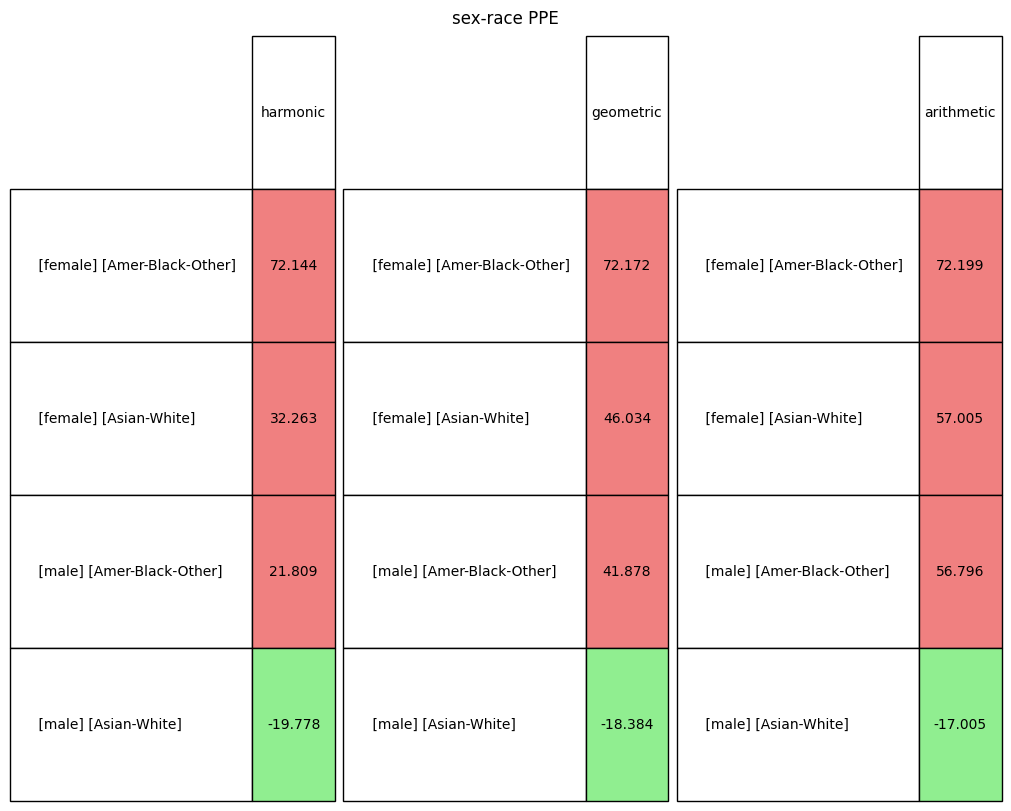

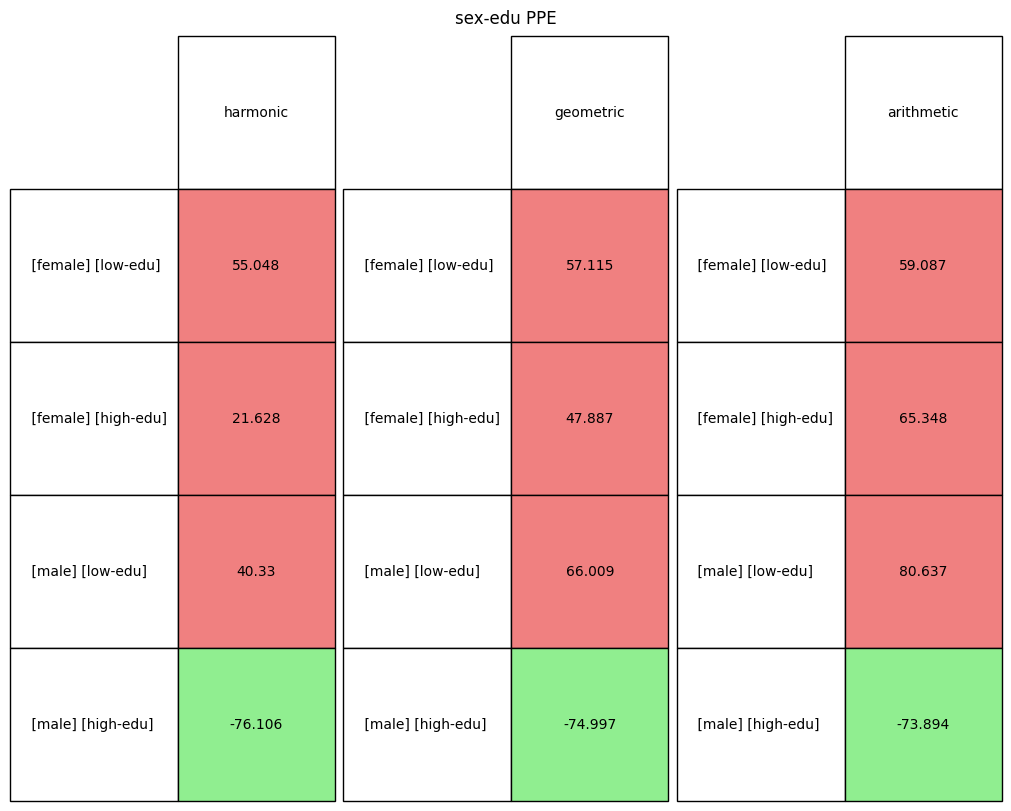

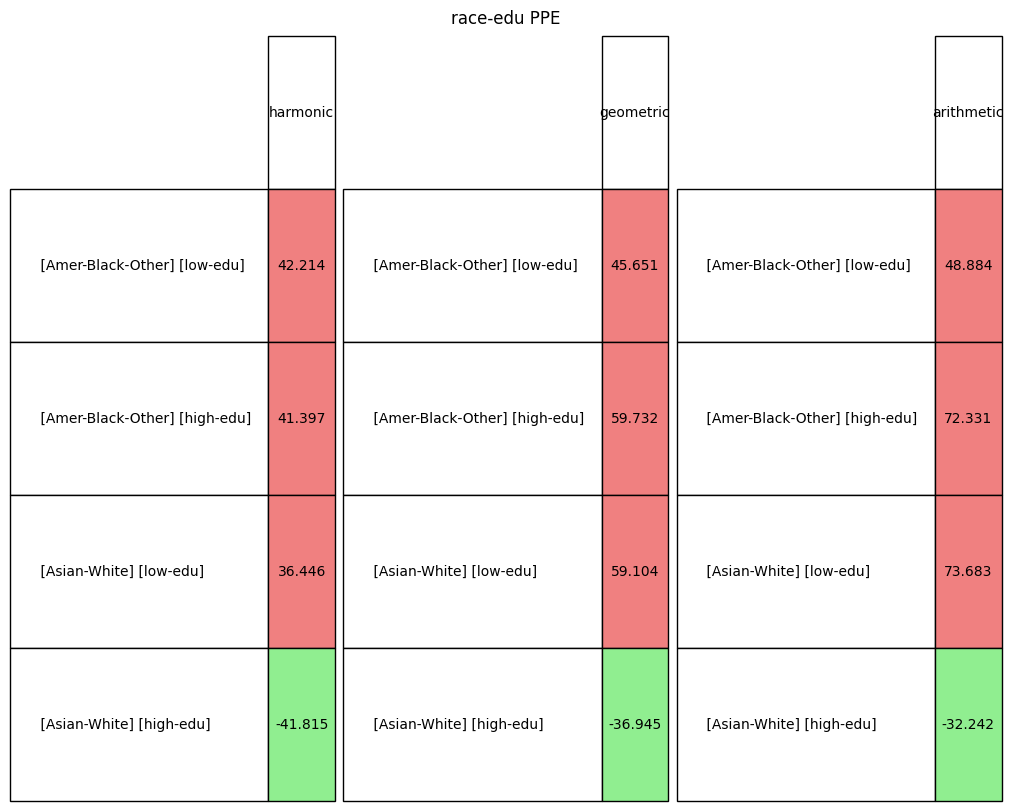

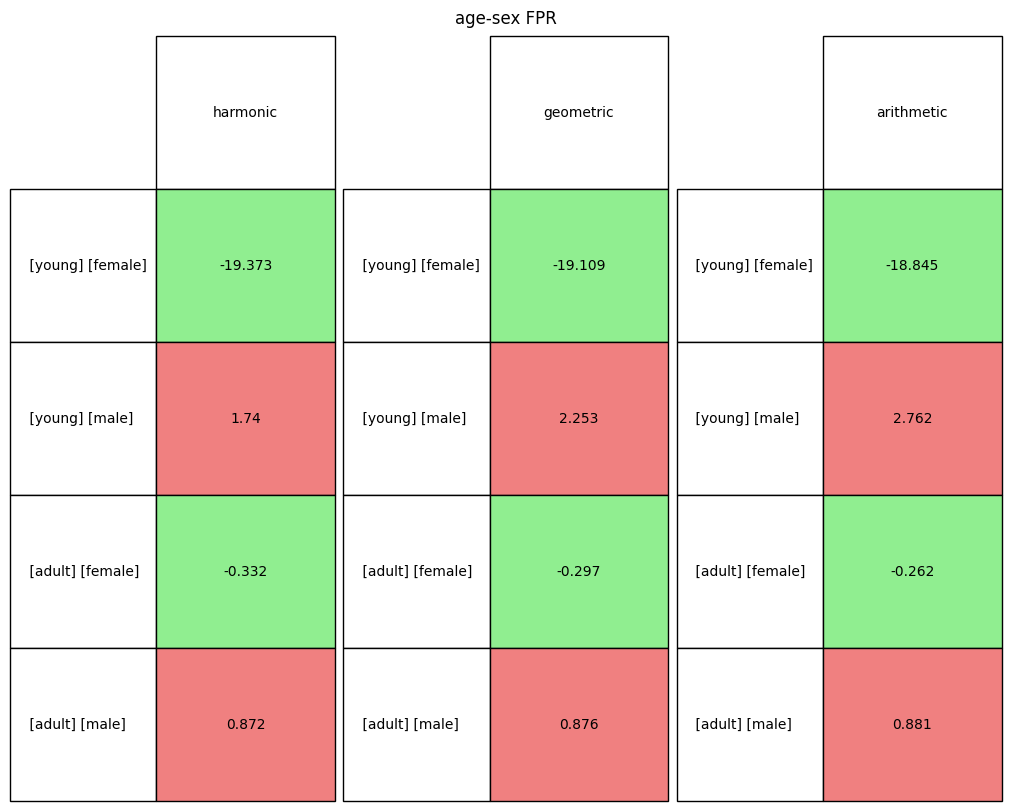

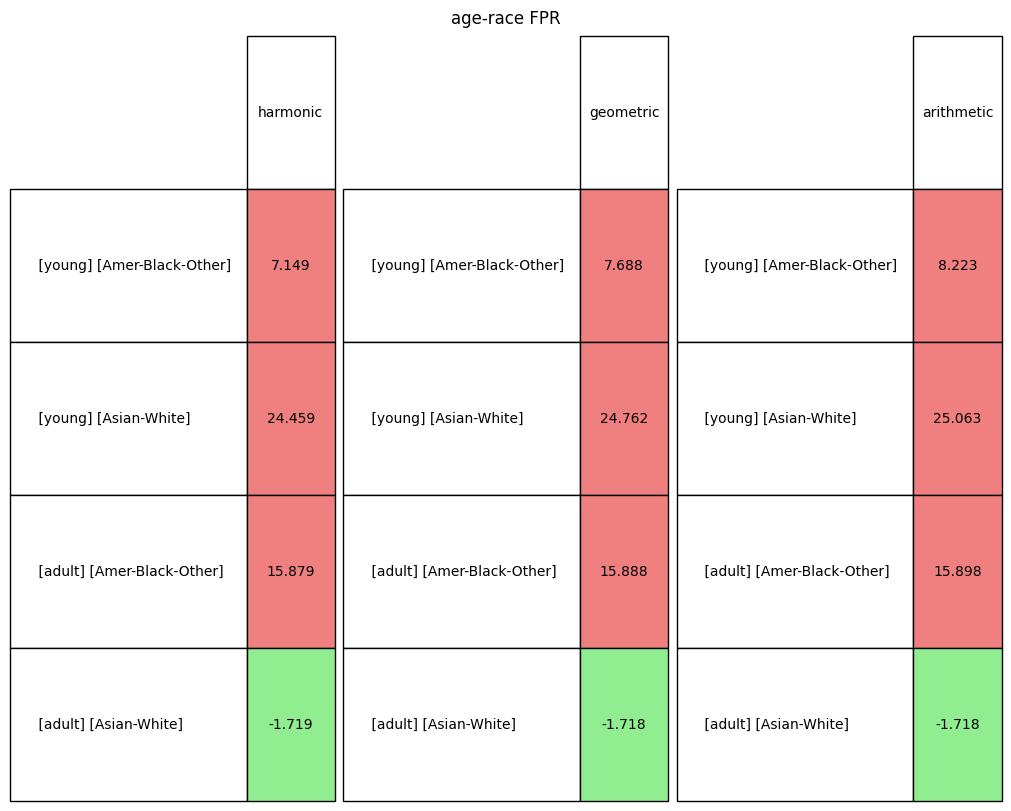

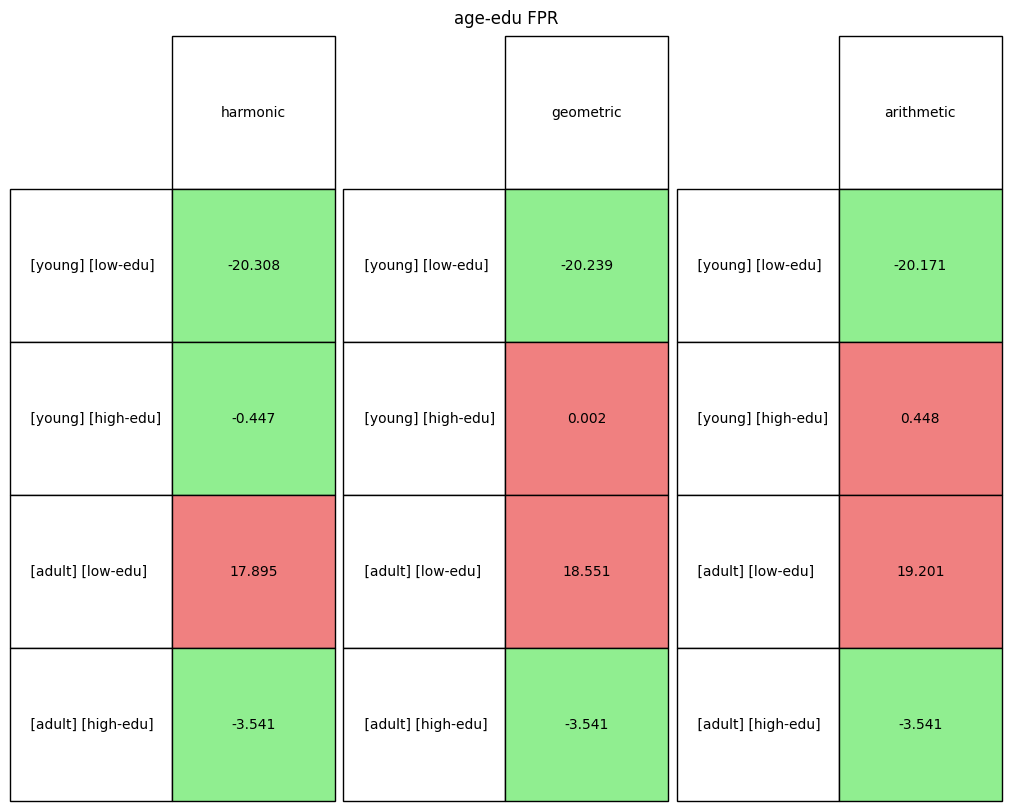

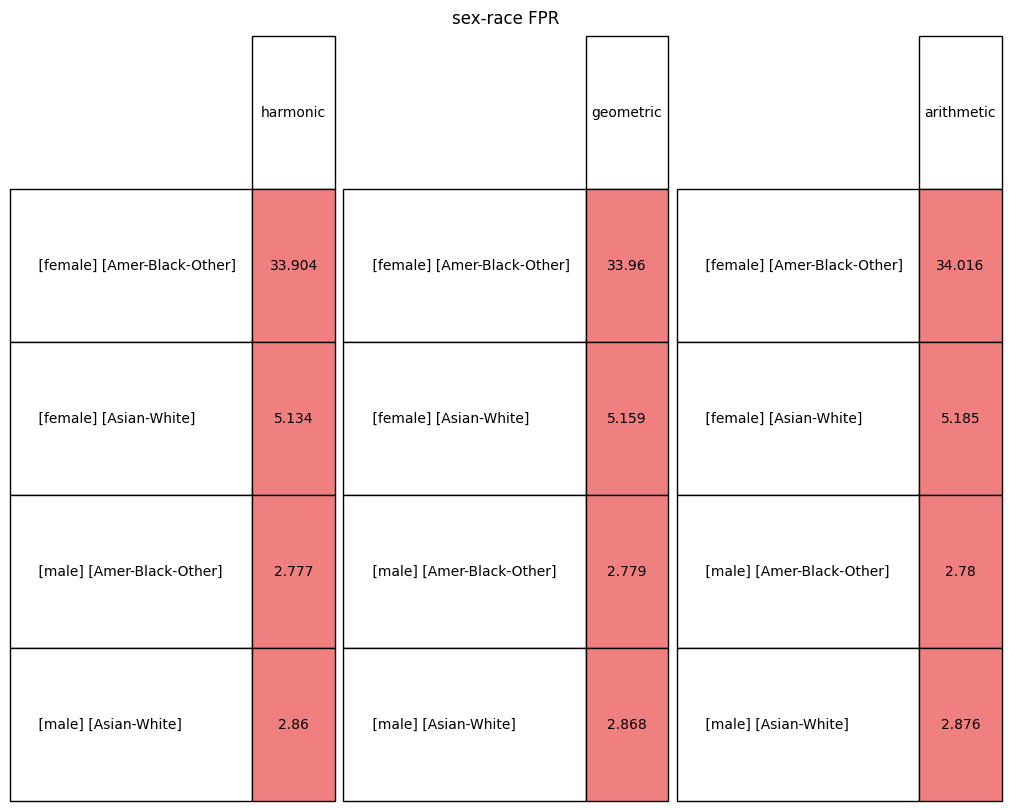

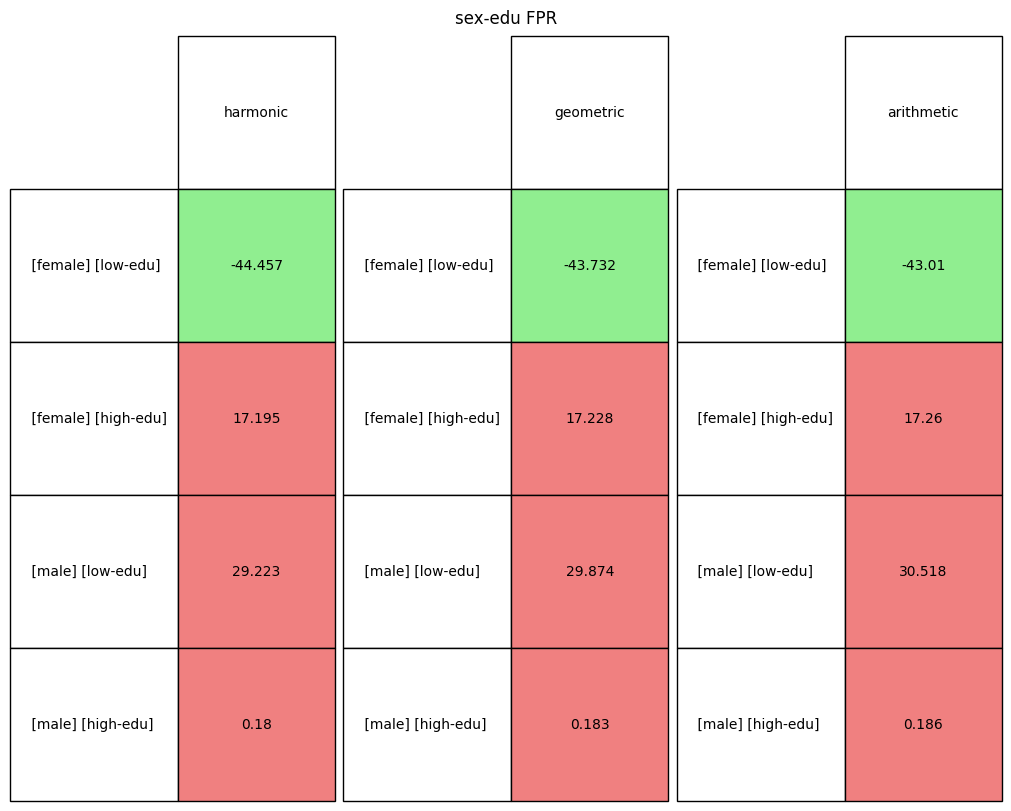

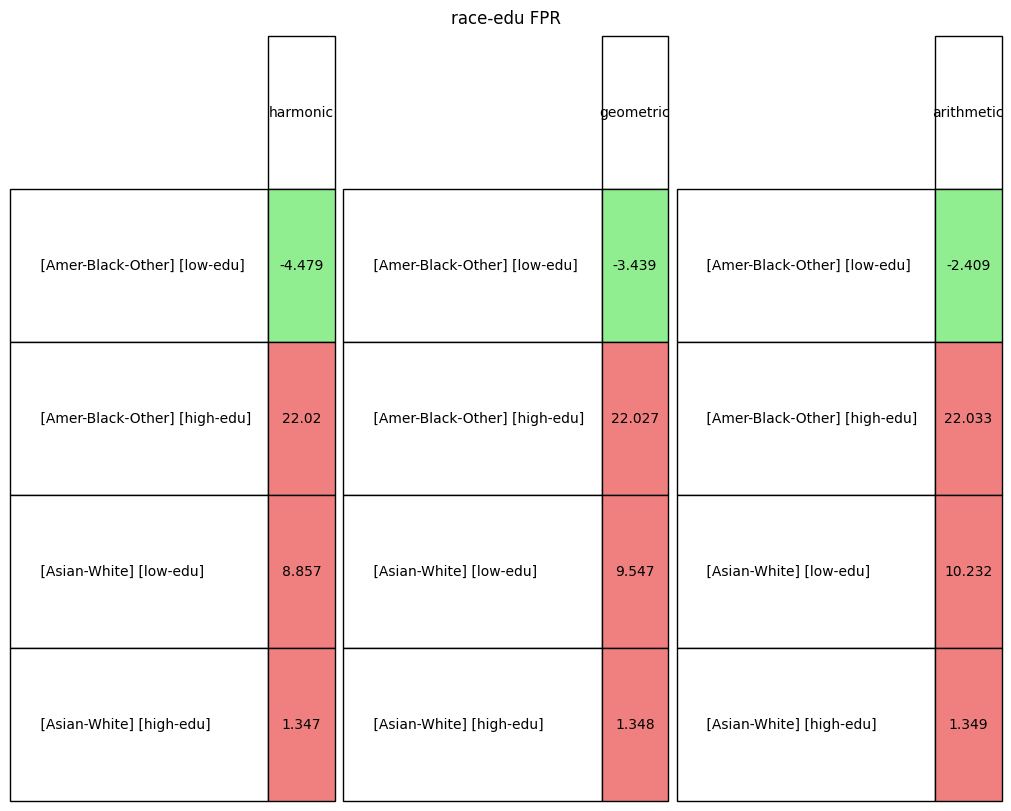

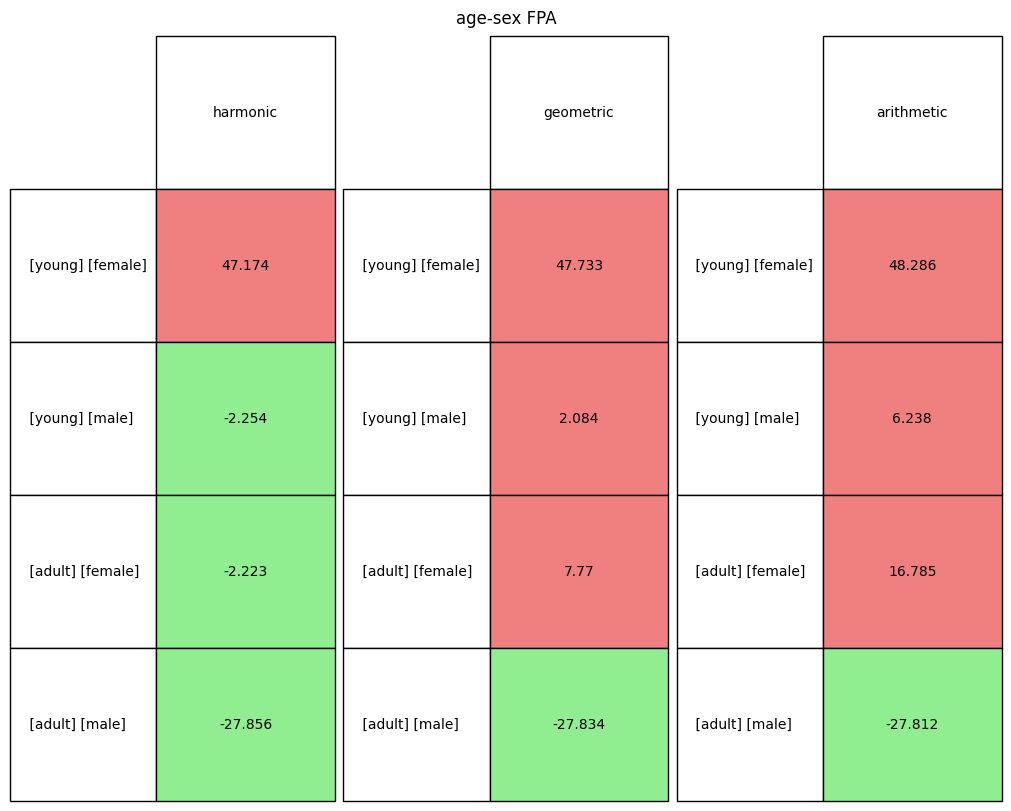

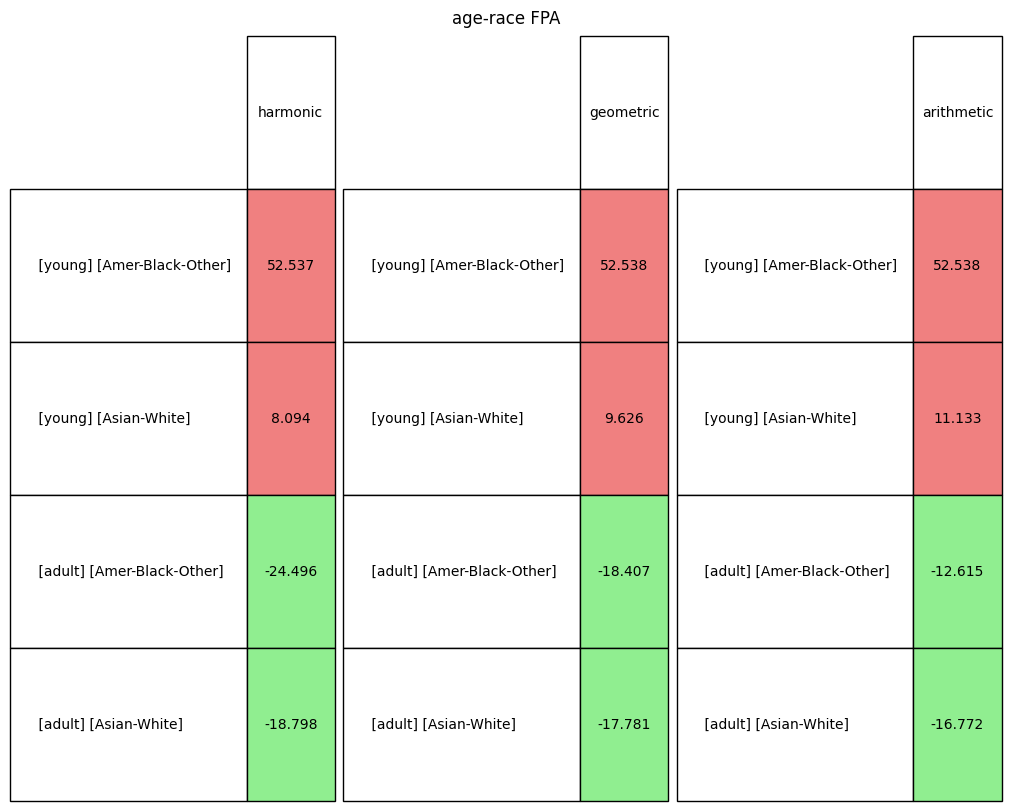

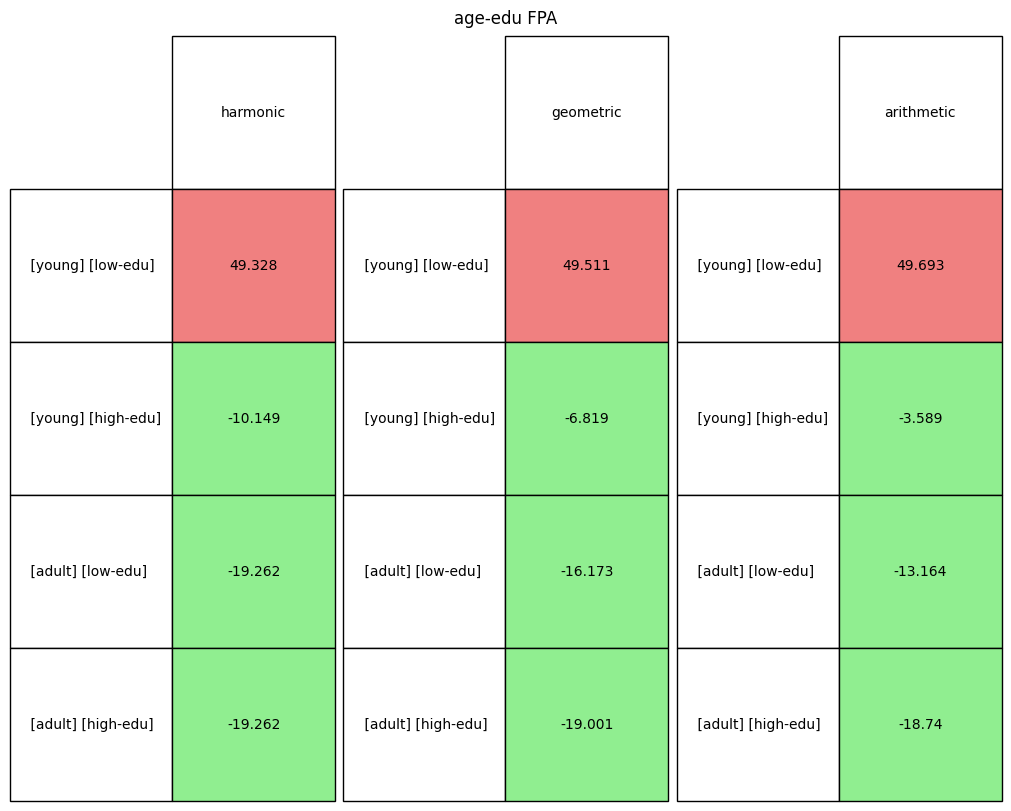

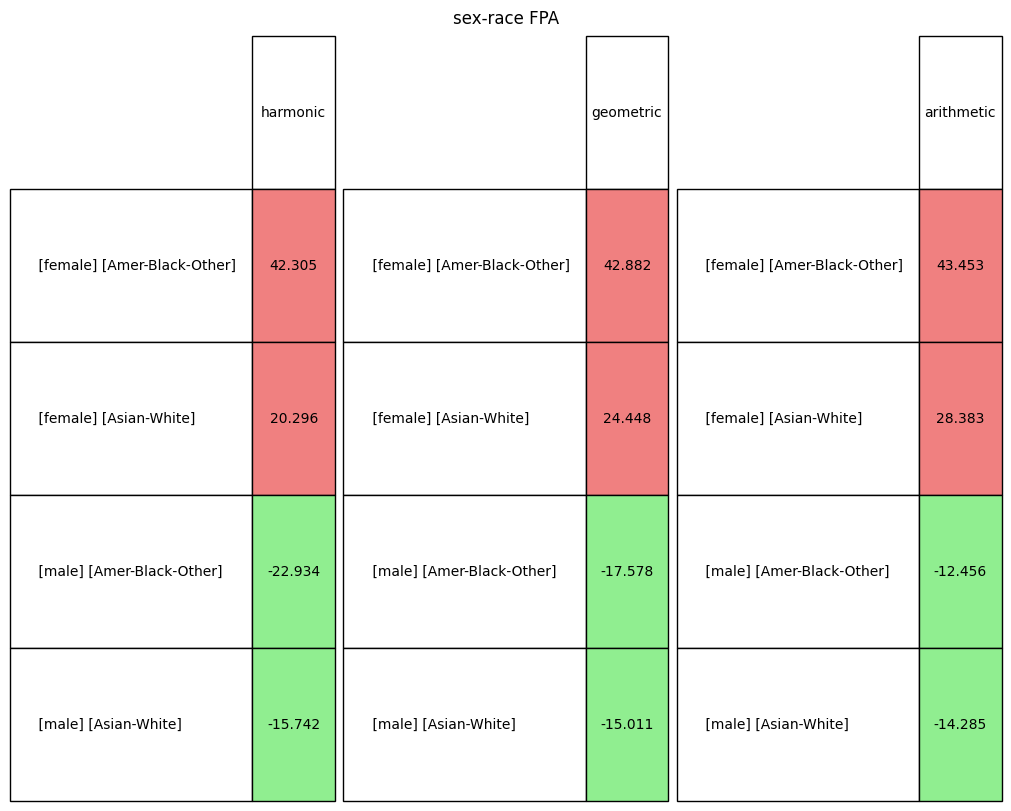

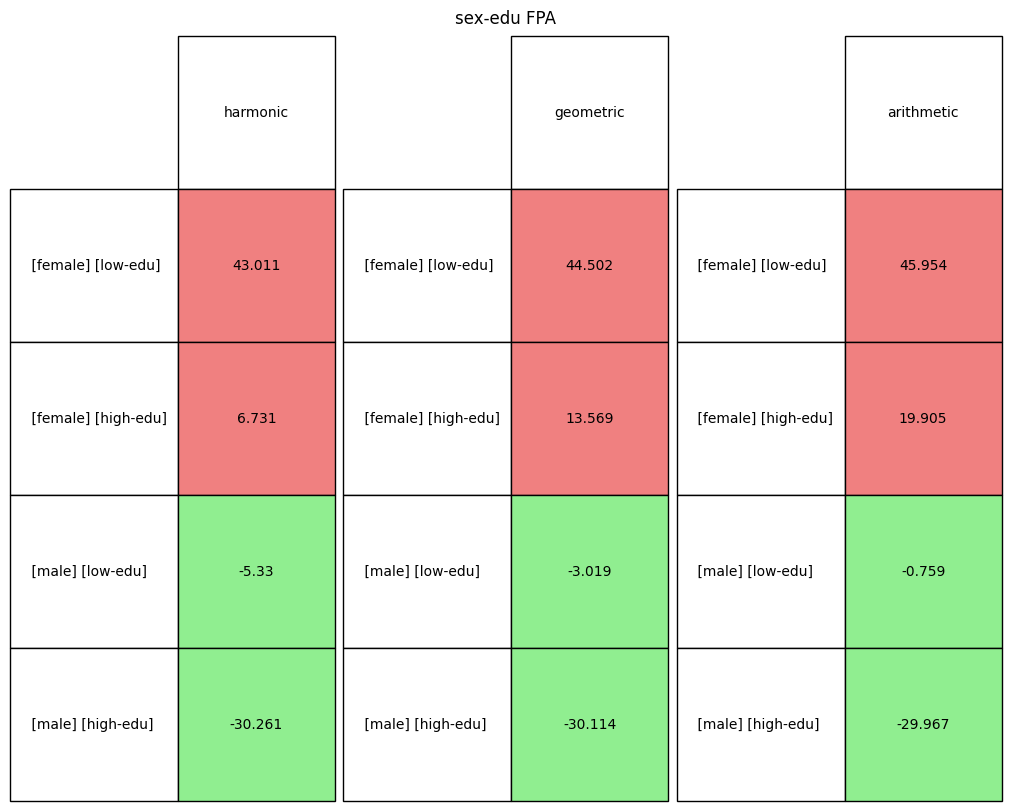

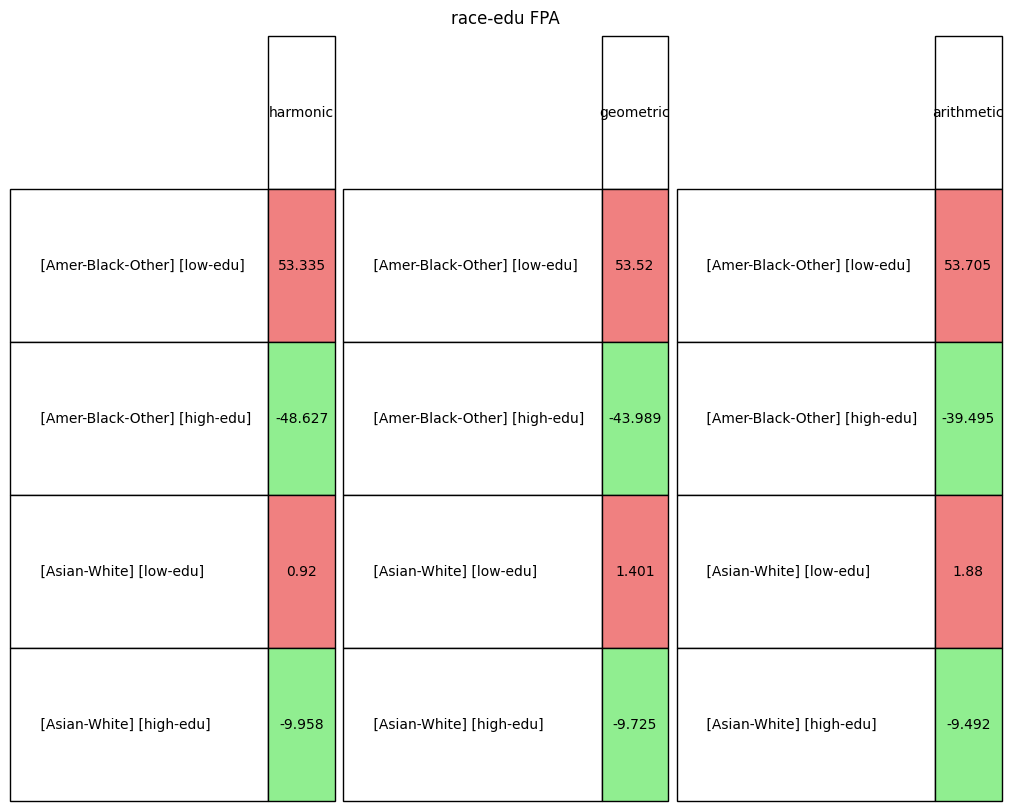

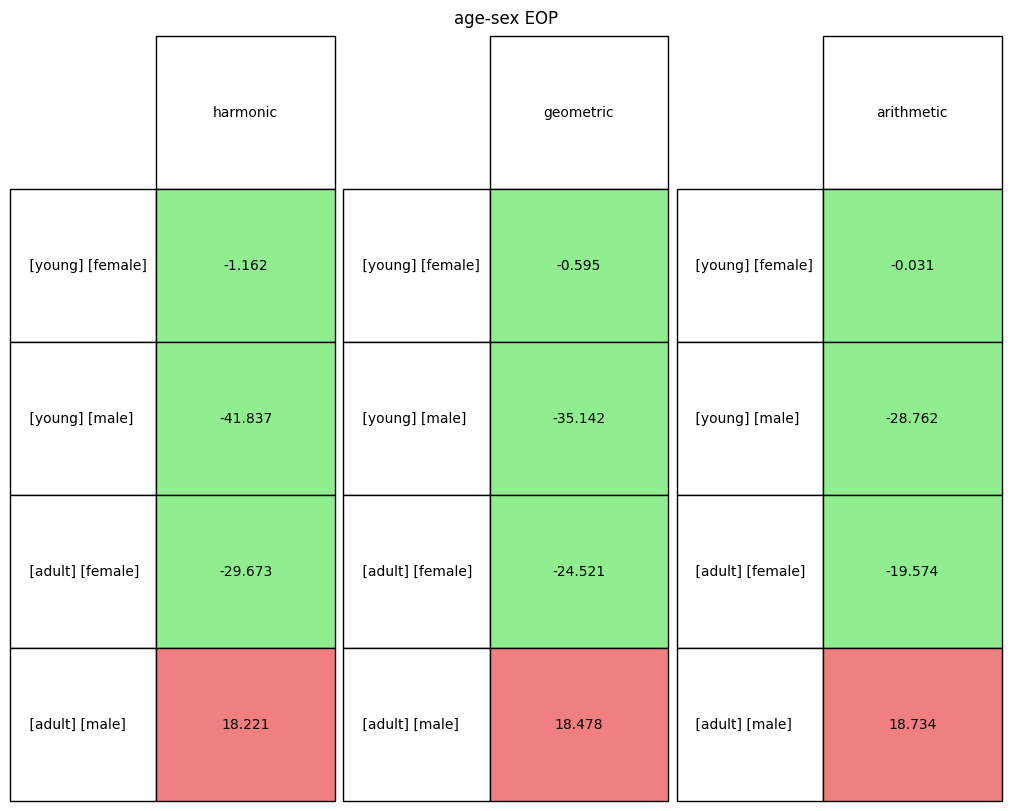

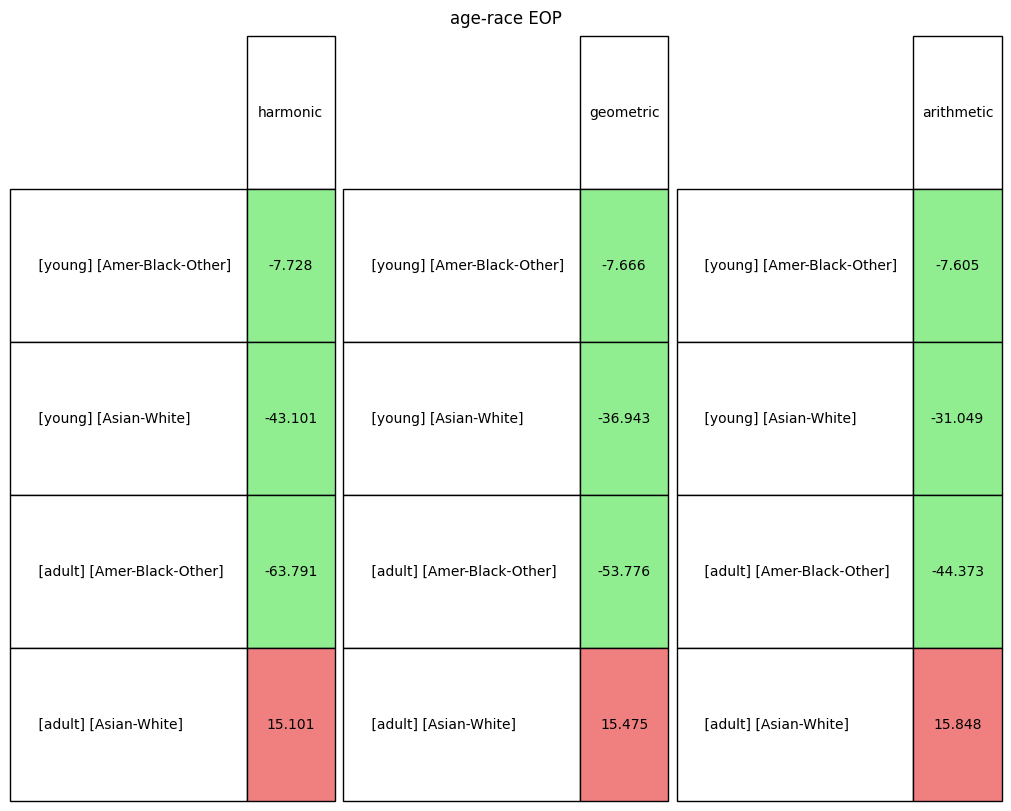

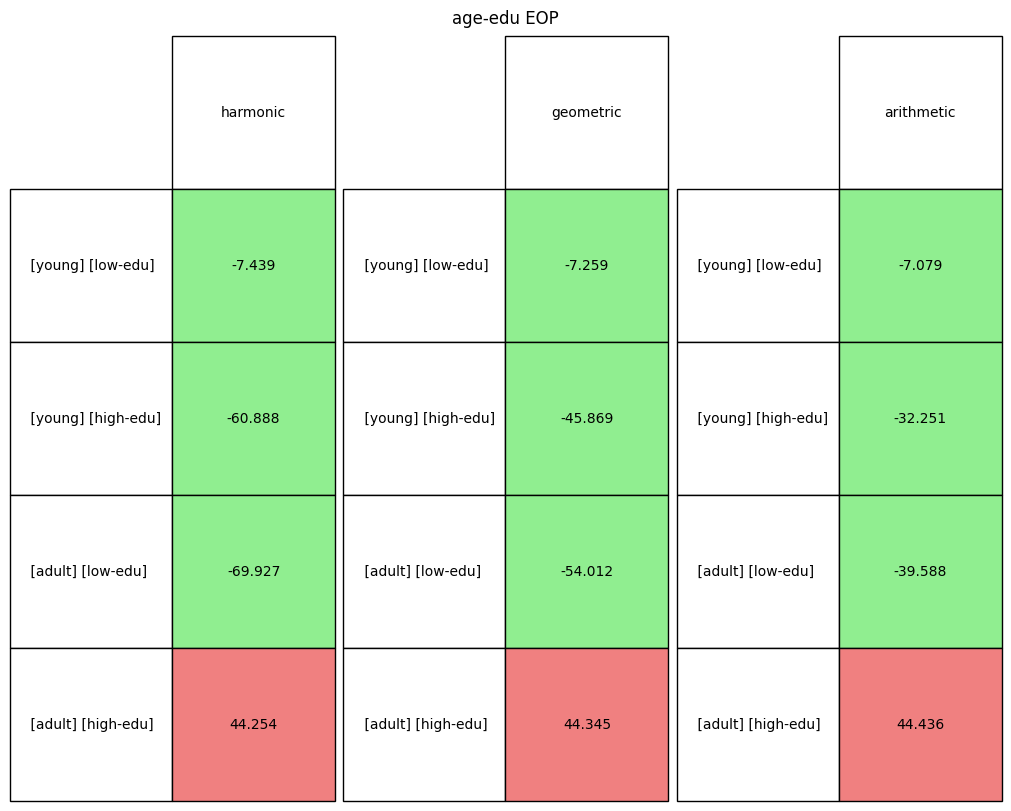

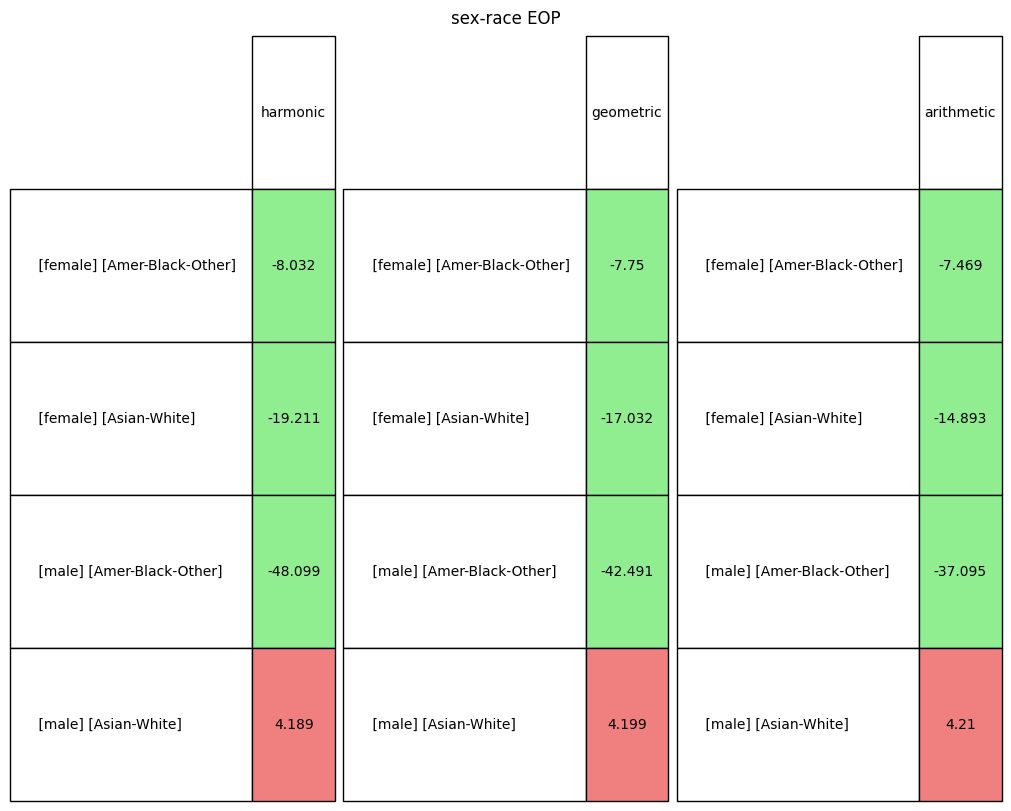

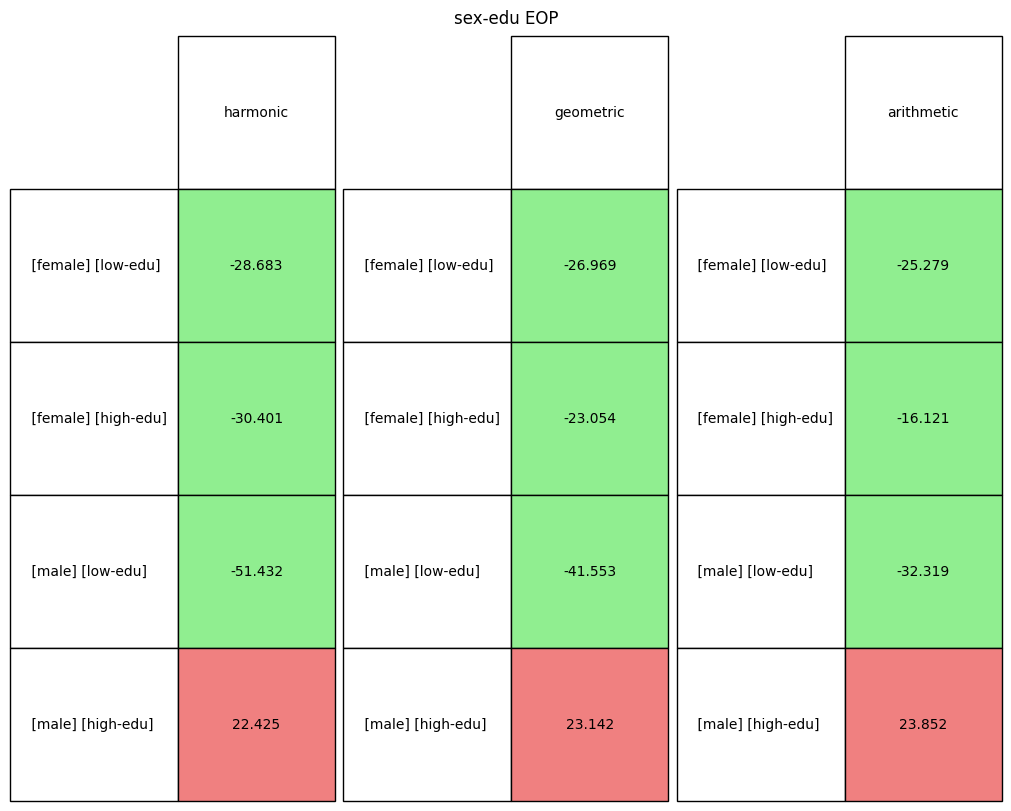

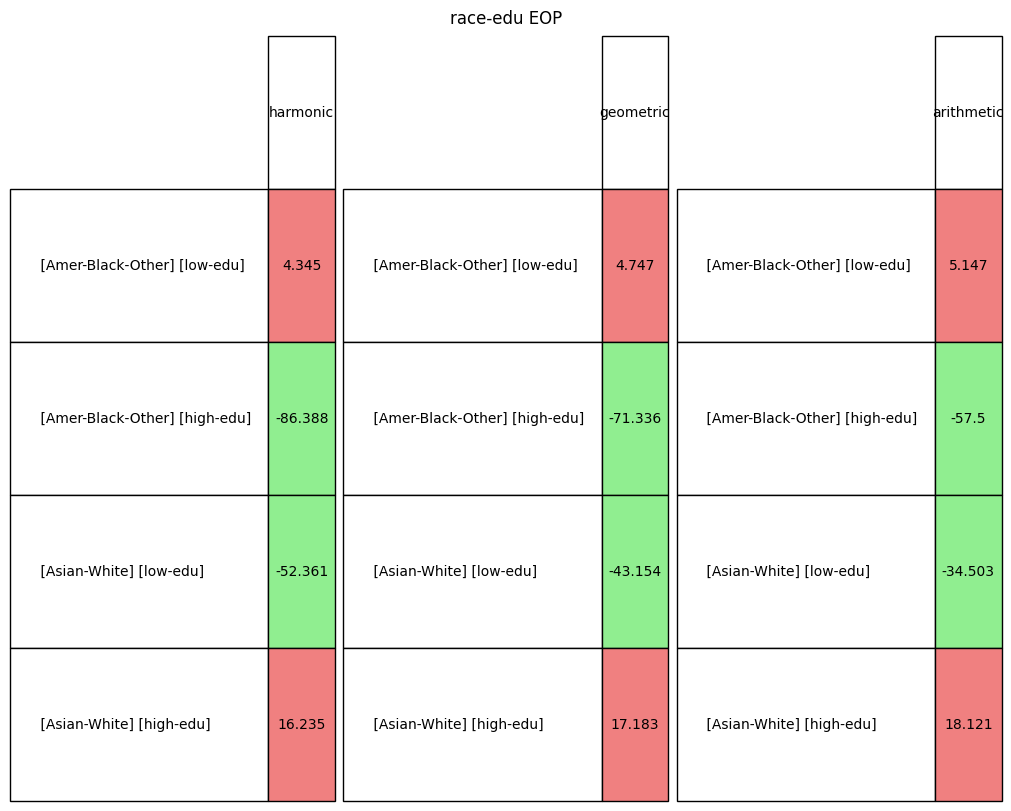

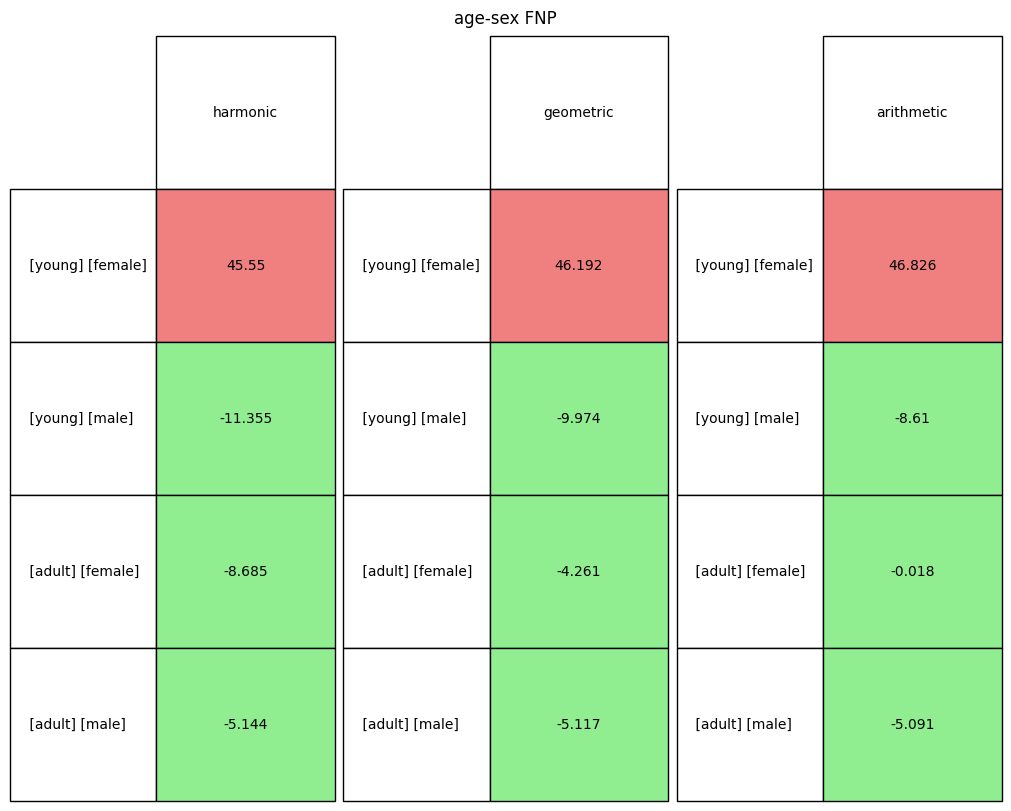

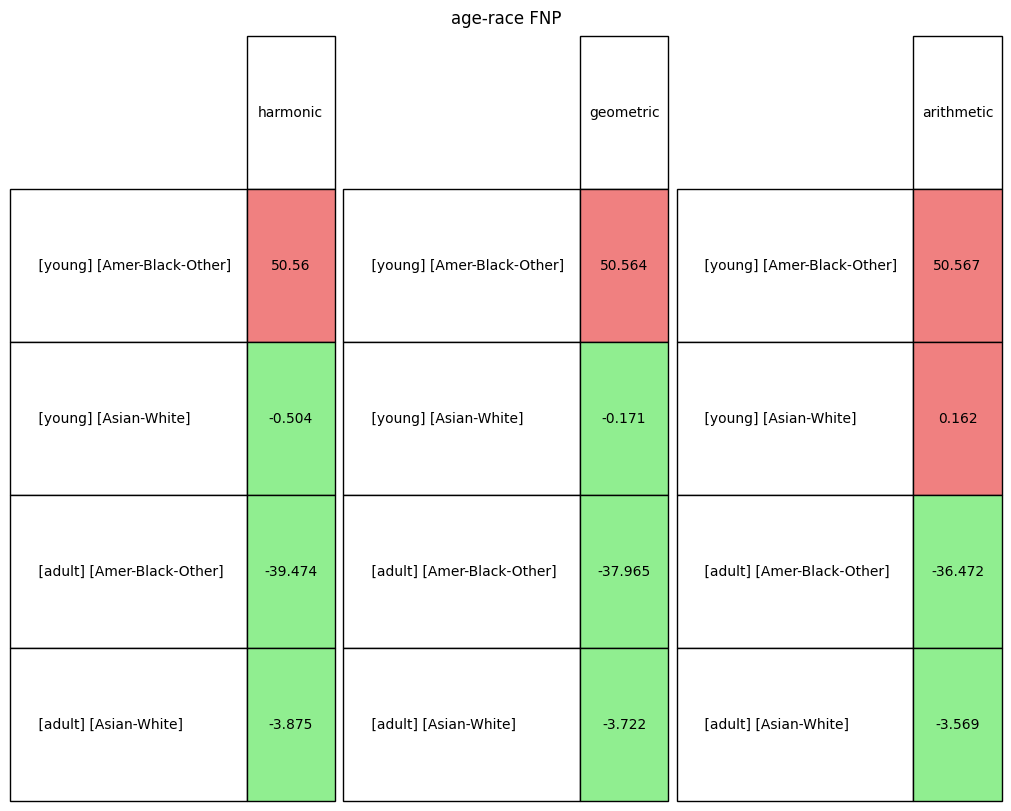

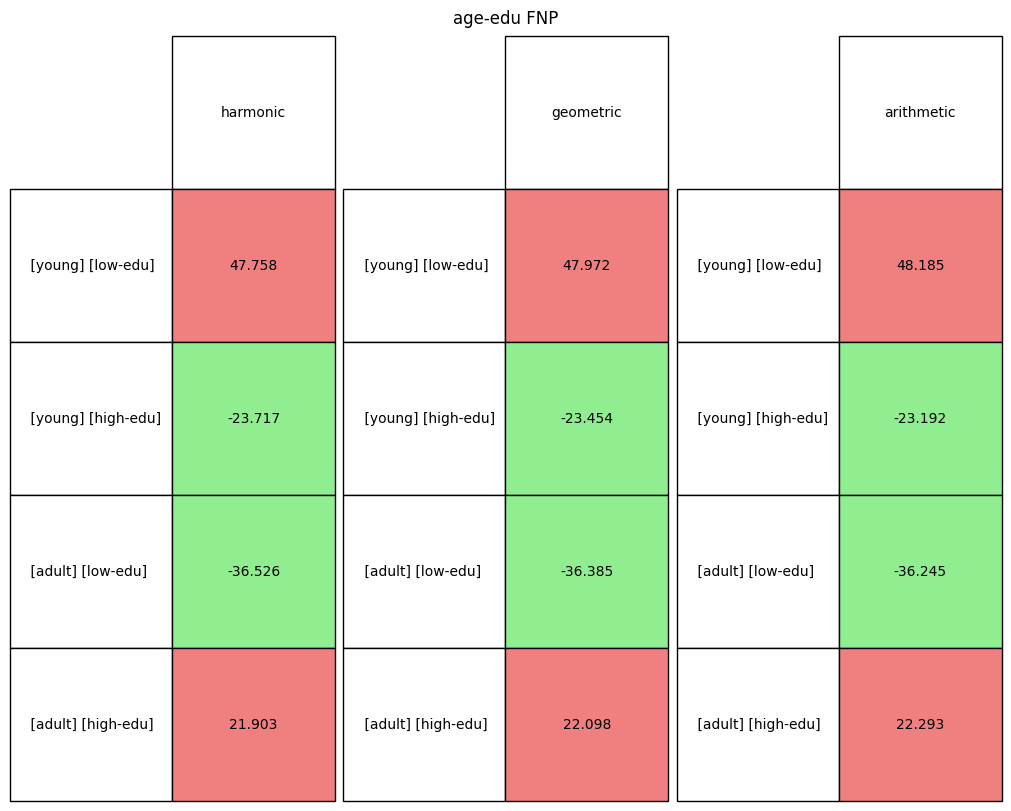

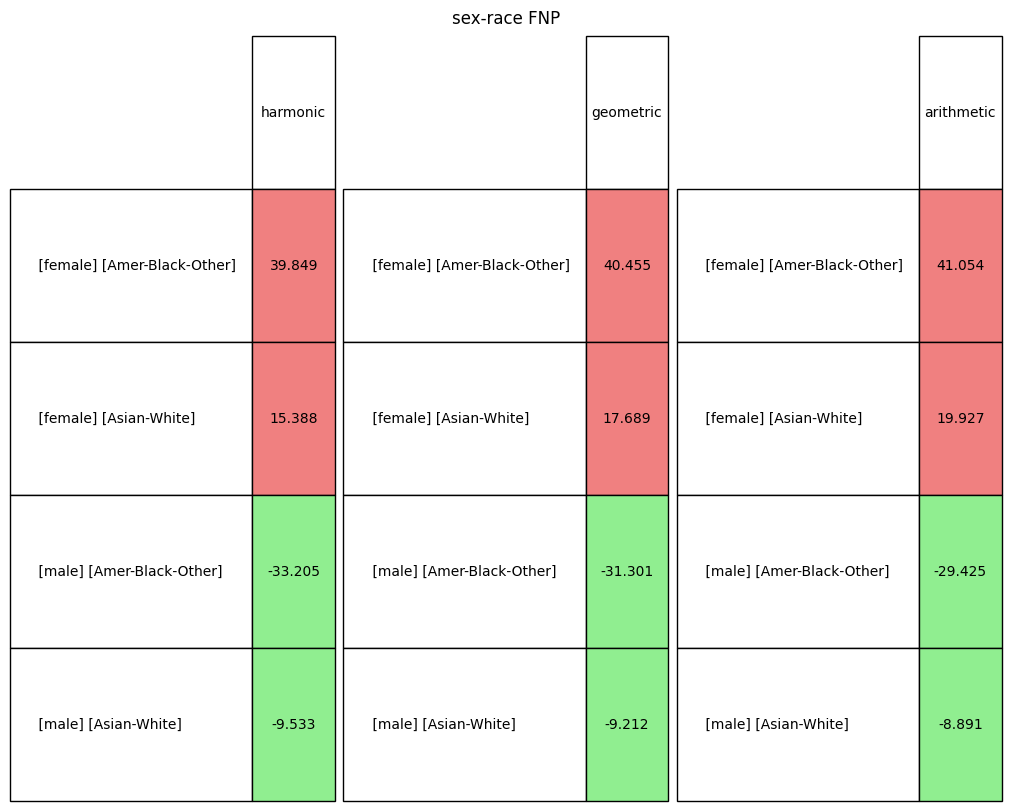

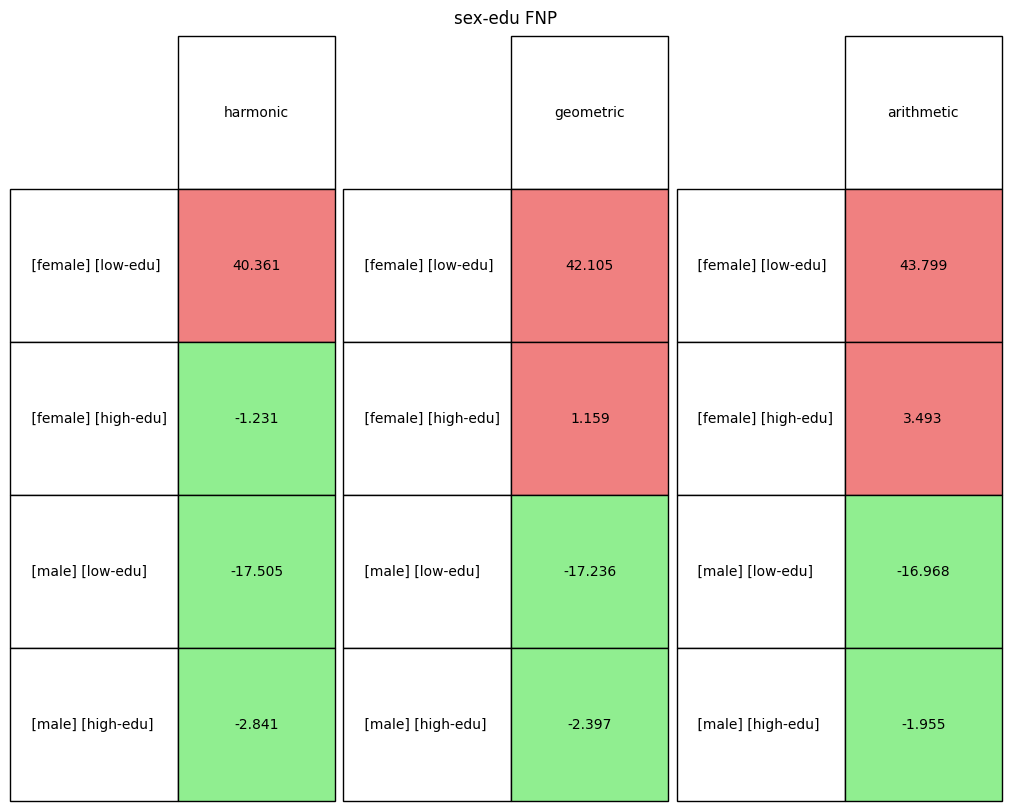

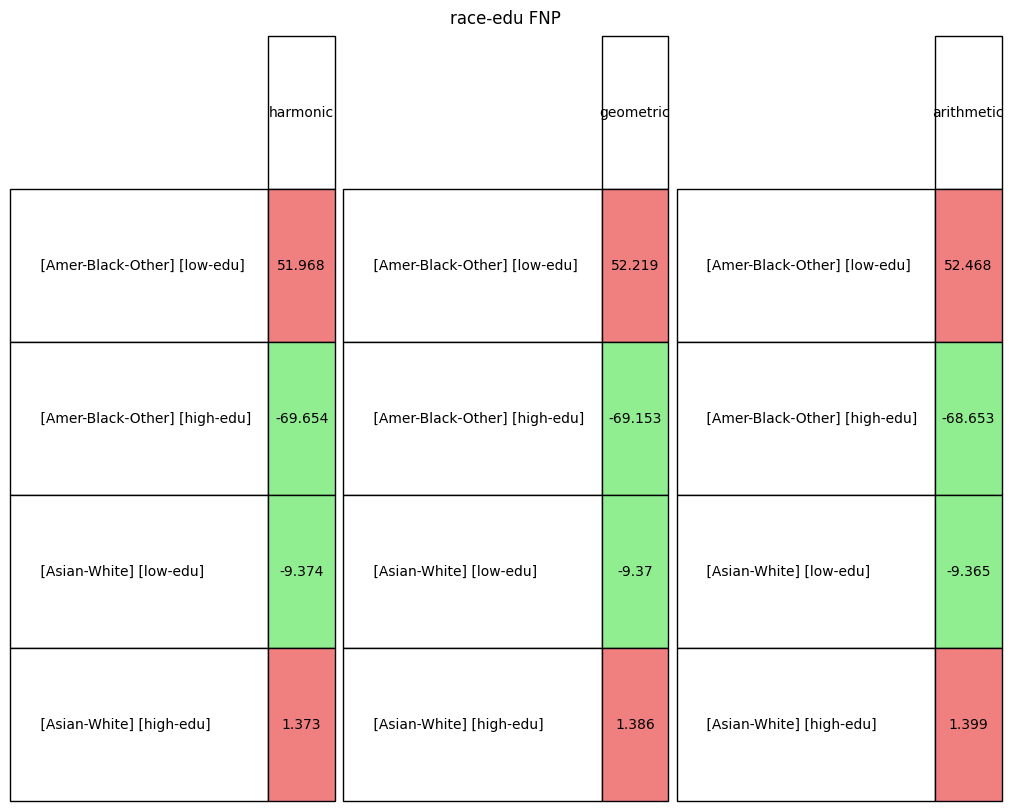

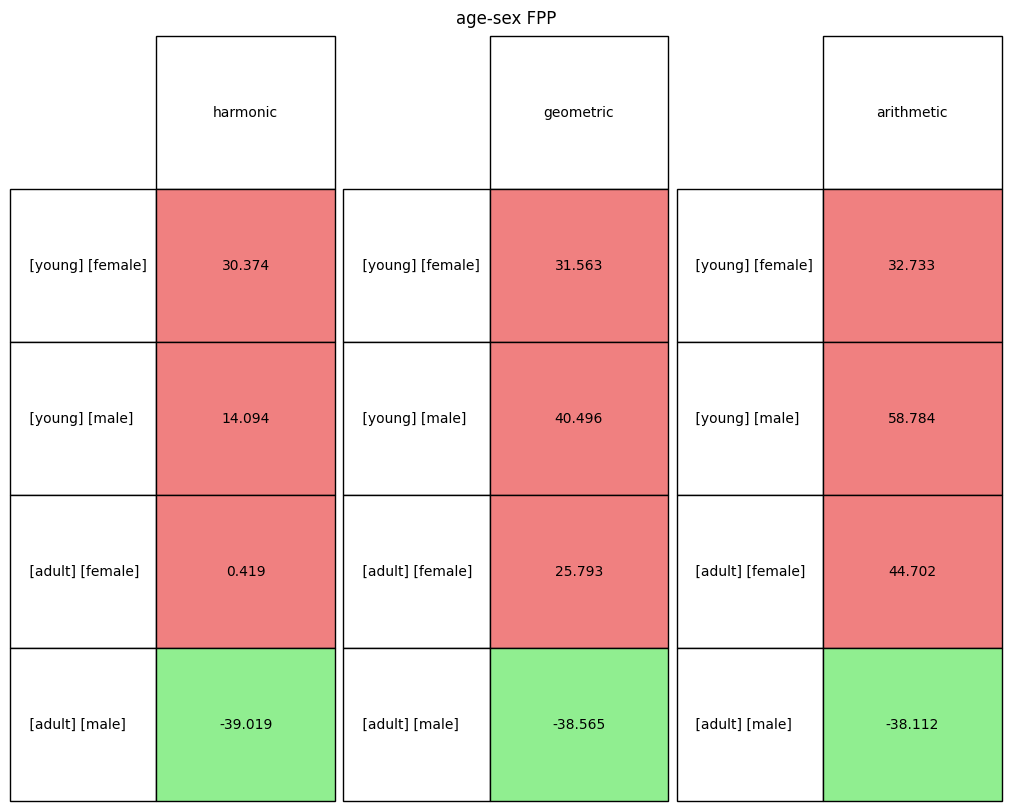

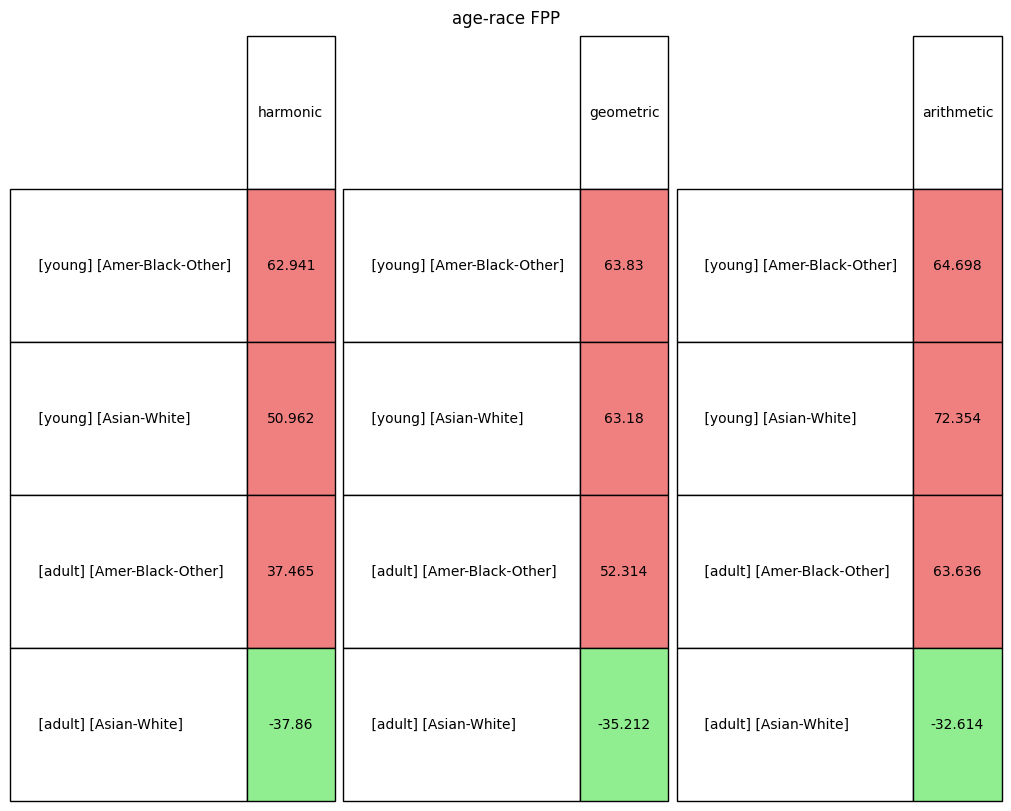

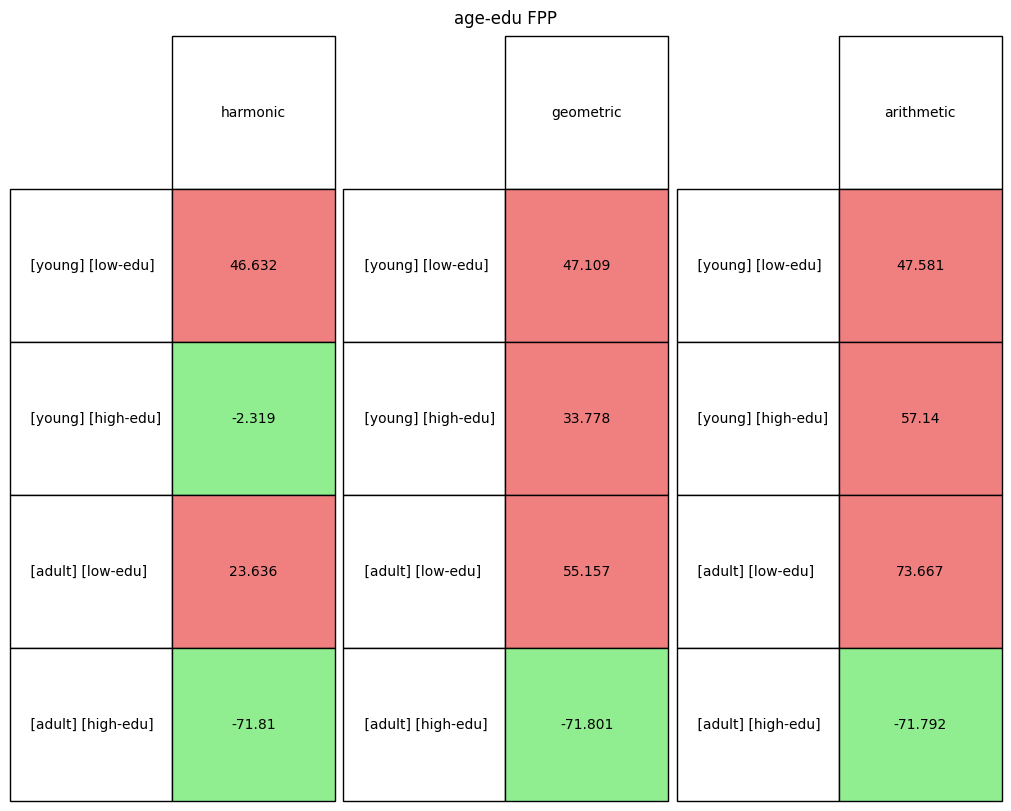

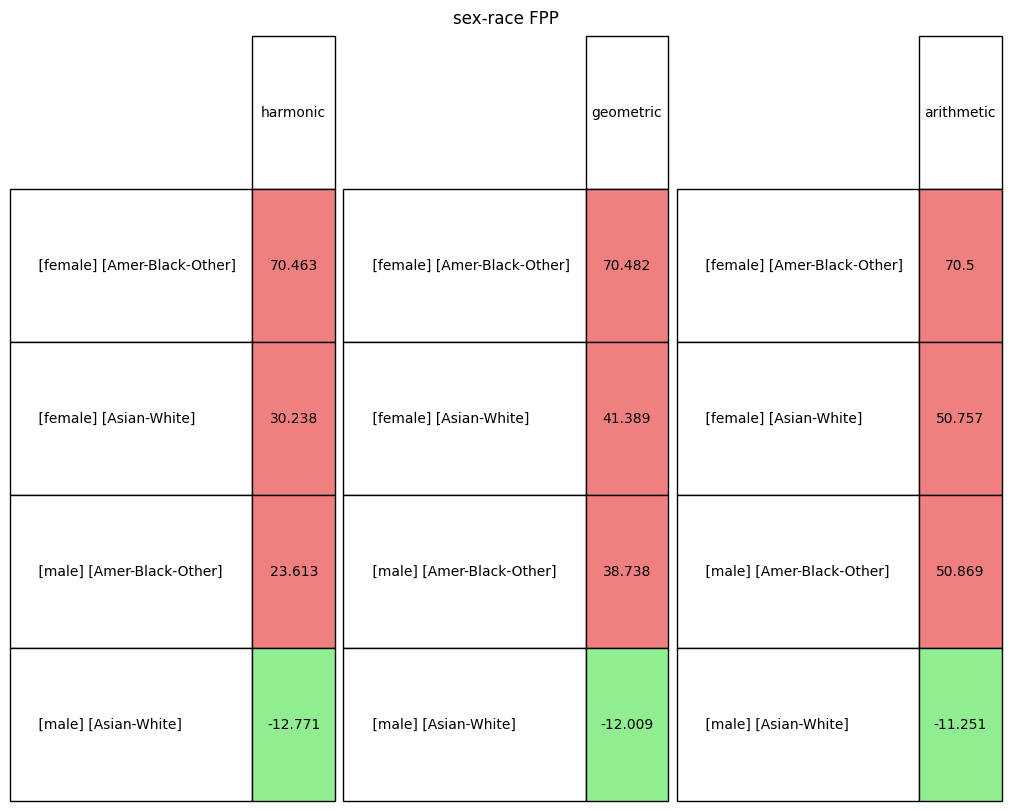

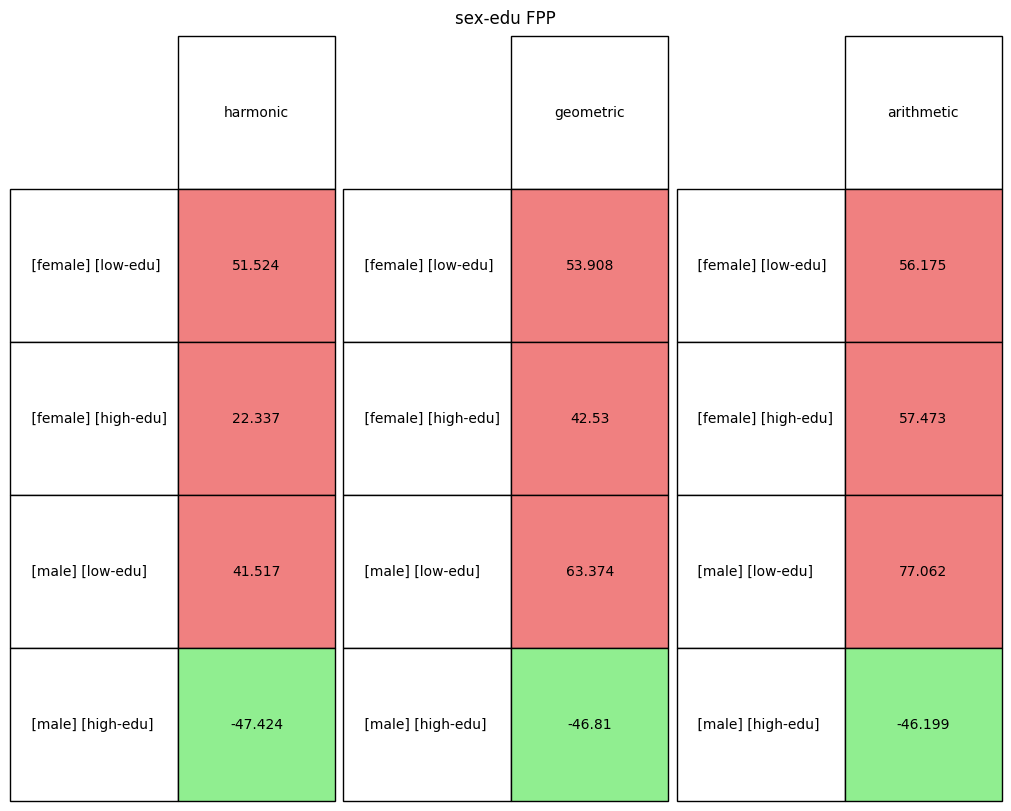

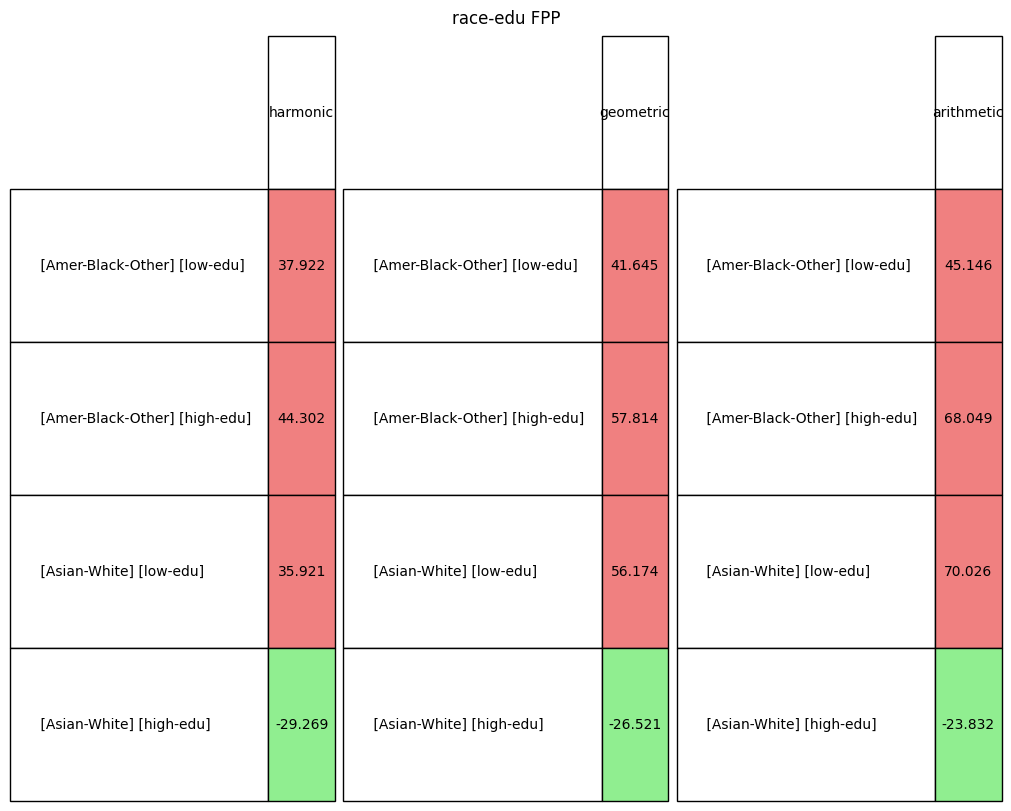

In [12]:
for m in fair_metrics:
  #print(m)
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      if len(s)==2:
        print_tables_penalty_2(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==3:
        #print_tables_penalty_3(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==4:
        #print_tables_penalty_4(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)

In [13]:
for m in fair_metrics:
  #print(m)
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      #if len(s)==2:
        #print_tables_penalty_2(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      if len(s)==3:
        print_tables_penalty_3(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==4:
        #print_tables_penalty_4(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)

Output hidden; open in https://colab.research.google.com to view.

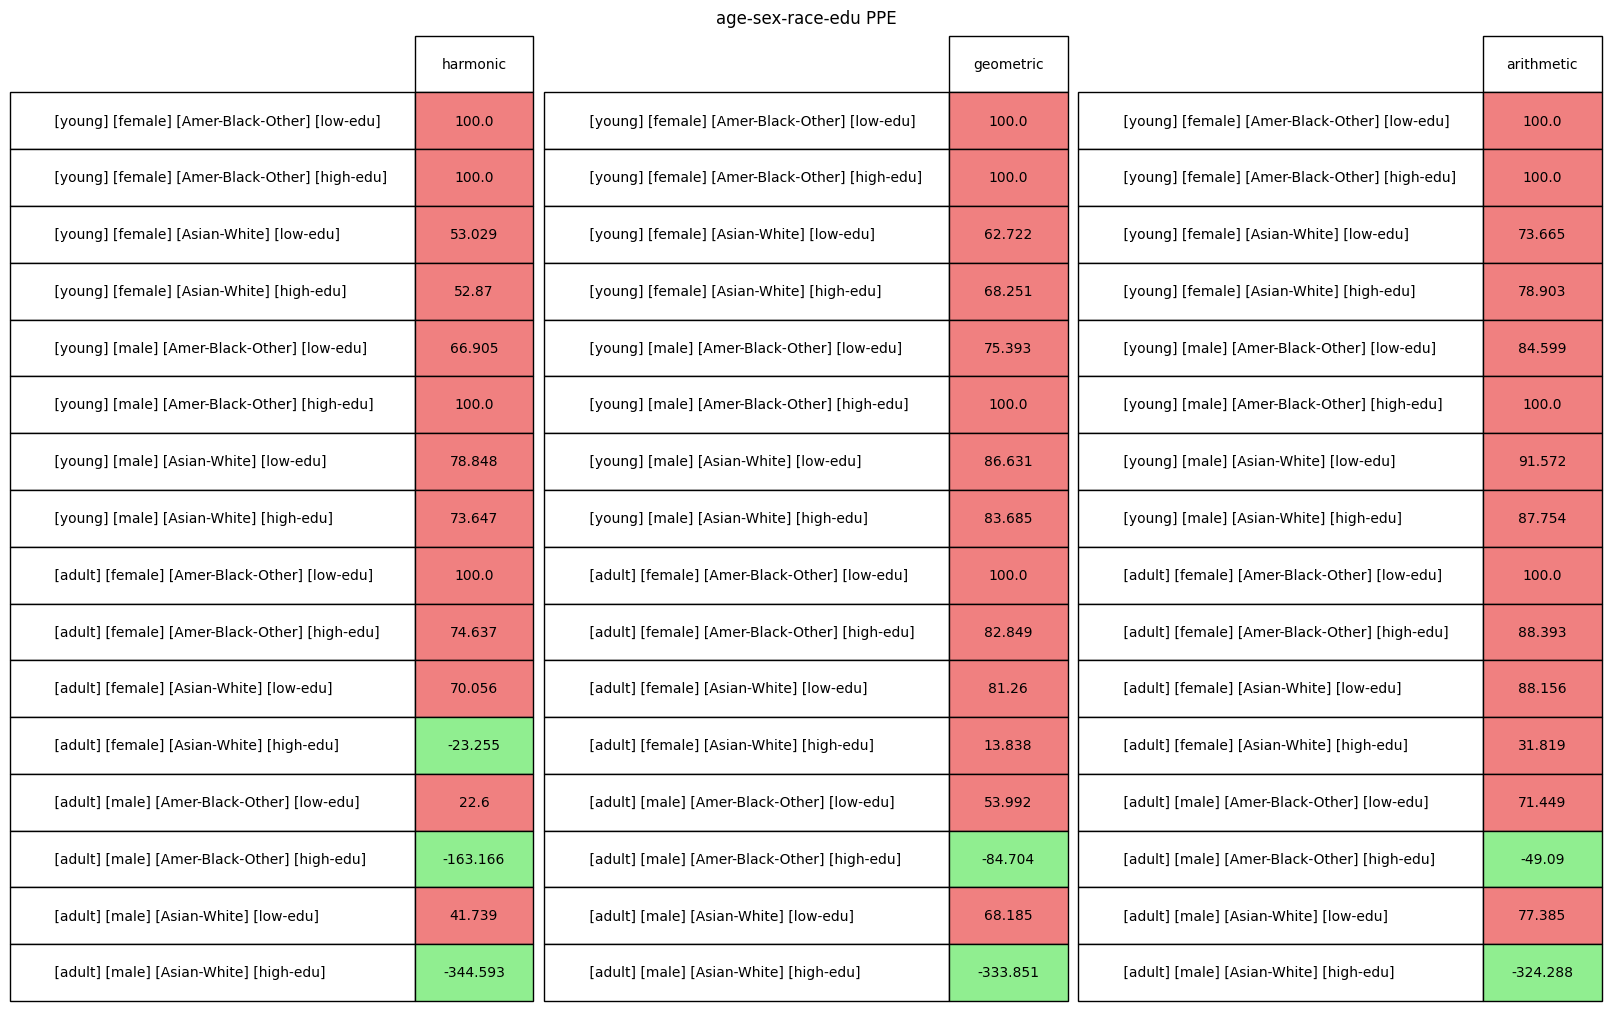

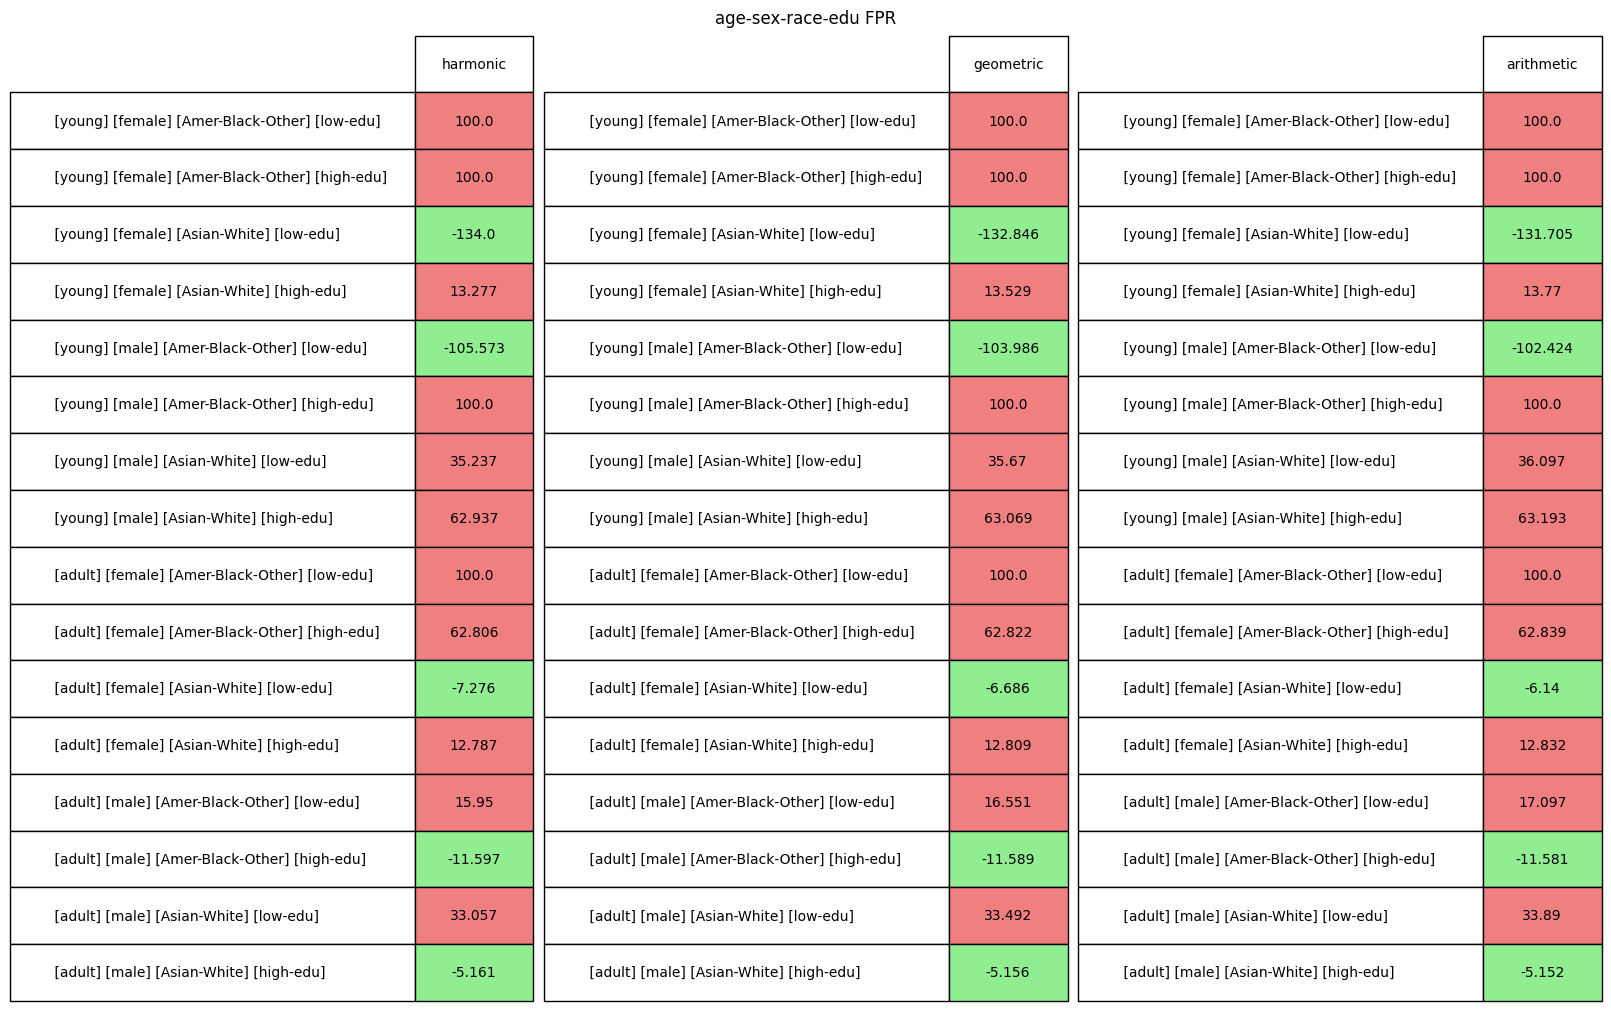

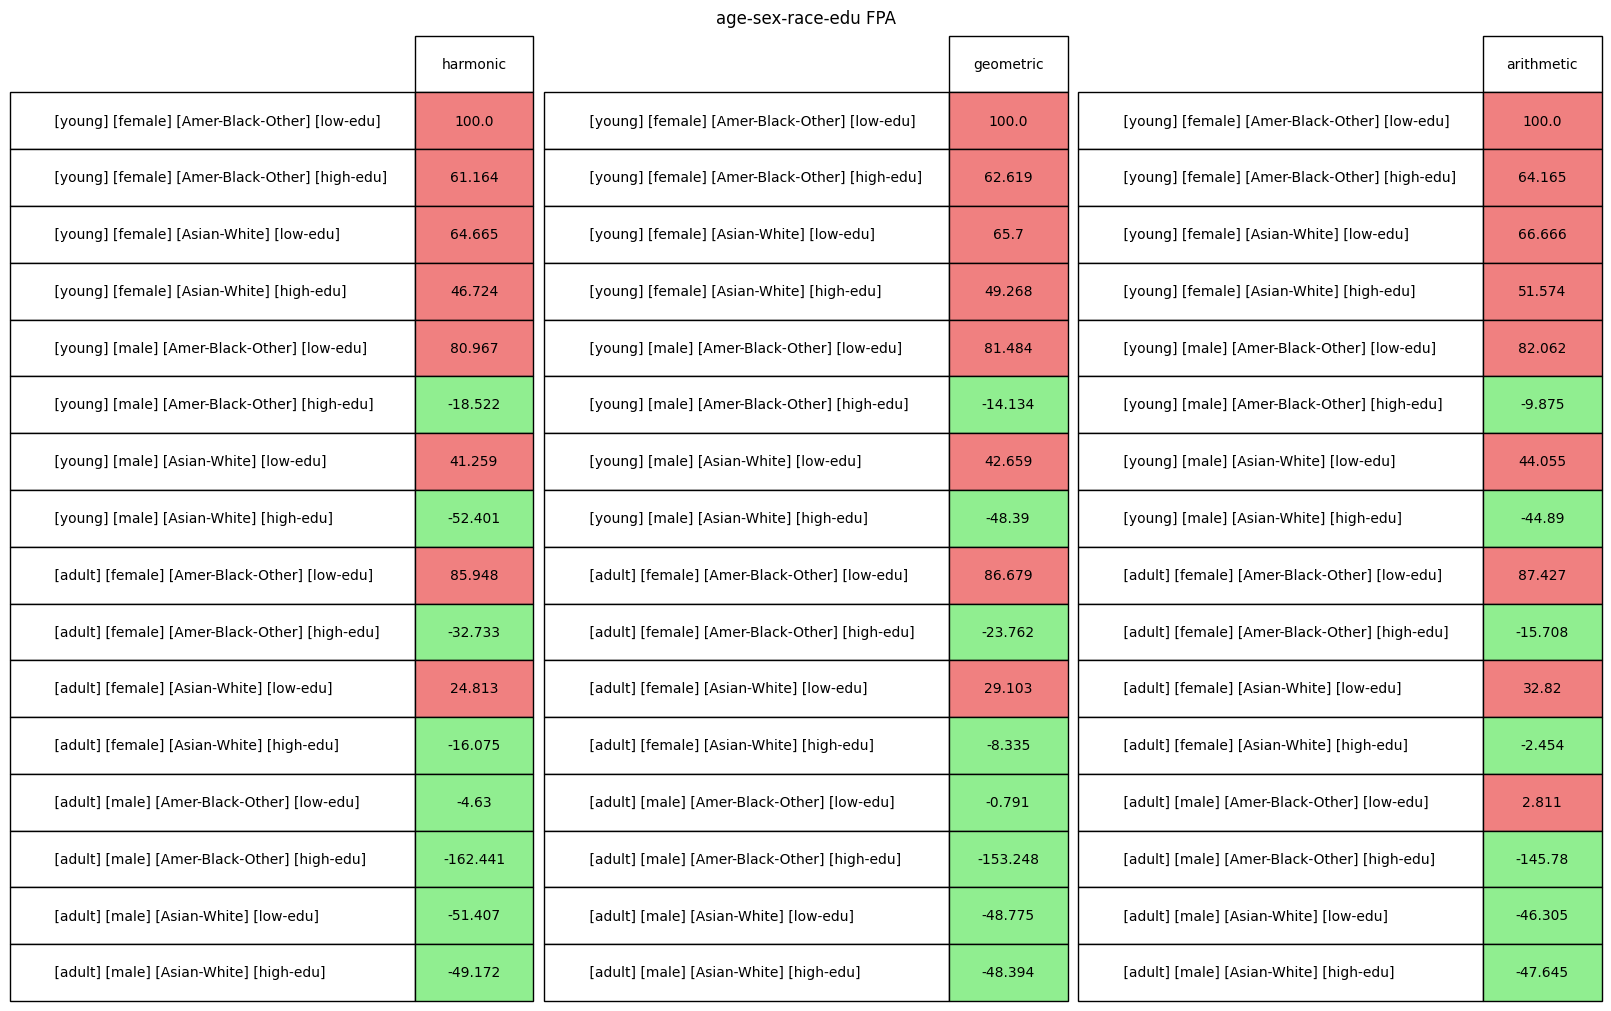

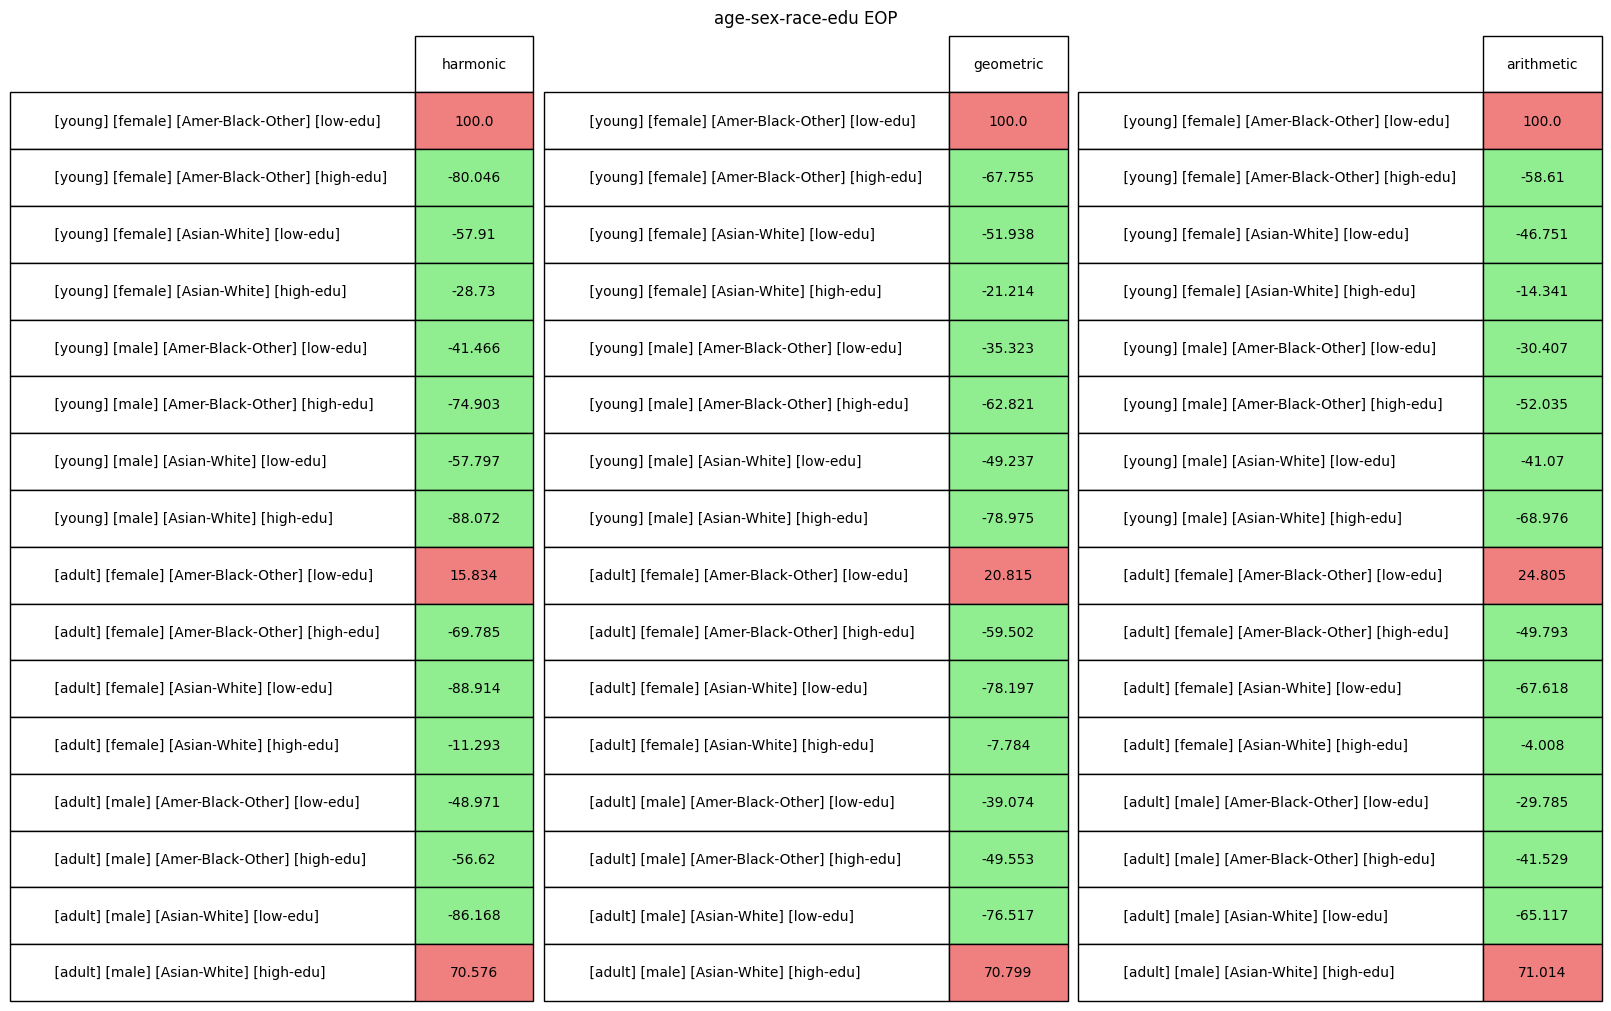

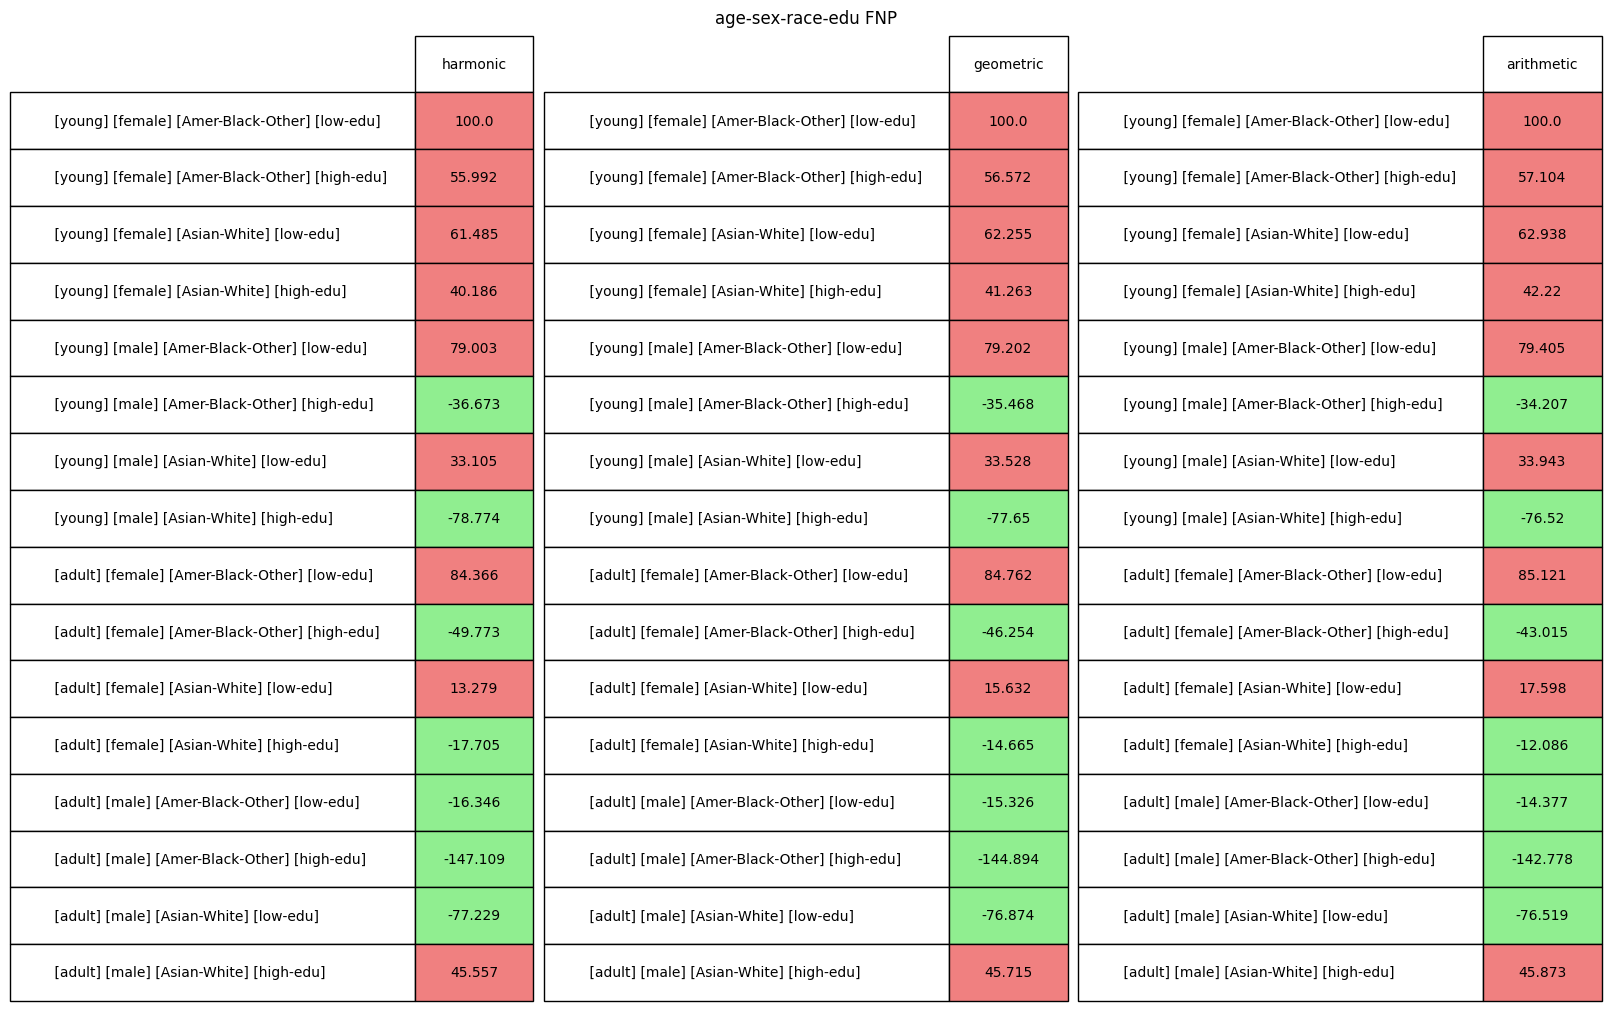

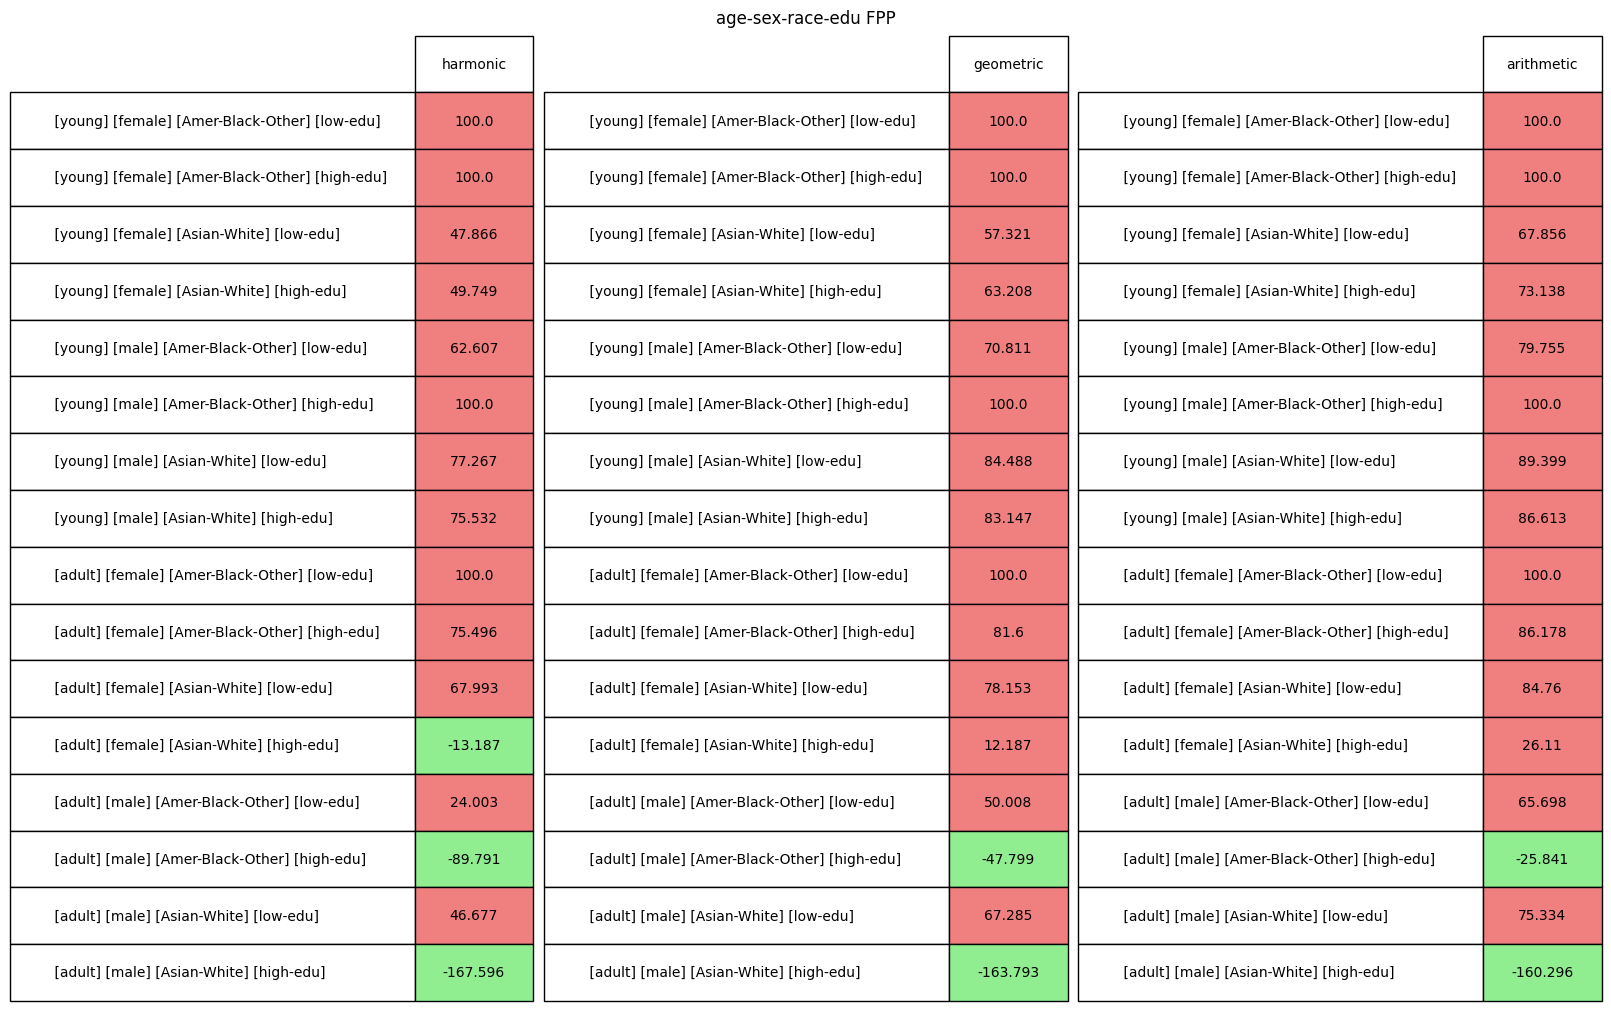

In [14]:
for m in fair_metrics:
  #print(m)
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      #if len(s)==2:
        #print_tables_penalty_2(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      #elif len(s)==3:
        #print_tables_penalty_3(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)
      if len(s)==4:
        print_tables_penalty_4(fairness_metrics_dict, df, sensible_attribute, m, mapping, dataset_path)

Age:
* 11> age > 30 --> 0
* 40> age >90 --> 1

EDU:
* 1> edu >9 --> 0
* 9> edu >16 --> 1

SEX:
* female --> 0
* male --> 1

RACE:
* 'Amer-Indian-Eskimo' , 'Black', 'Other'--> 0
* 'Asian-Pac-Islander', 'White' --> 1,



In [15]:
print('done')

done
